# Setup

In [ ]:
#leveraging the hugging face libraries for transformers and datasets
!pip install transformers[sentencepiece]
!pip install datasets
!pip install evaluate

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import transformers
import datasets
import evaluate

from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

from datasets import load_metric, load_dataset, concatenate_datasets, list_metrics
from sklearn.metrics import ConfusionMatrixDisplay

# Models and Datasets loading

## Models

### RoBERTa large MNLI

A transformer-based model pre-trained on English language using a masked language modeling (MLM) objective, fine-tuned on the *Multi-Genre Natural Language Inference* (MNLI) corpus (https://huggingface.co/FacebookAI/roberta-large-mnli).

In [ ]:
#loading RoBERTa large MNLI tokenizer and model
roBERTaTokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-large-mnli")
roBERTa = AutoModelForSequenceClassification.from_pretrained("FacebookAI/roberta-large-mnli")

### mDeBERTa-v3 base XNLI



A multilingual transformer model introduced by Microsoft, pre-trained on the *CC100 multilingual dataset* (with 100 languages) and fine-tuned on the *Cross-lingual Natural Language Inference* (XNLI) and multilingual-NLI-26lang datasets (https://huggingface.co/MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7).

In [ ]:
mDeBERTaTokenizer = AutoTokenizer.from_pretrained("MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7")
mDeBERTa = AutoModelForSequenceClassification.from_pretrained("MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7")

### RoBERTa large SNLI MNLI FEVER ANLI


A strong pre-trained RoBERTa-Large model for natural language inference involving SNLI, MNLI, *Fact Extraction and VERification* (FEVER-NLI) and *Adversarial Natural Language Inference* (ANLI) datasets (https://huggingface.co/ynie/roberta-large-snli_mnli_fever_anli_R1_R2_R3-nli).

In [ ]:
roBERTaLTokenizer = AutoTokenizer.from_pretrained("ynie/roberta-large-snli_mnli_fever_anli_R1_R2_R3-nli")
roBERTaL = AutoModelForSequenceClassification.from_pretrained("ynie/roberta-large-snli_mnli_fever_anli_R1_R2_R3-nli")

### DeBERTa-v3 large MNLI FEVER ANLI

A model based on DeBERTa-v3-large from Microsoft and fine-tuned on MNLI, Fever-NLI, ANLI, LingNLI and WANLI datasets (https://huggingface.co/MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli).

In [ ]:
deBERTaLTokenizer = AutoTokenizer.from_pretrained("MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli")
deBERTaL = AutoModelForSequenceClassification.from_pretrained("MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli")

### Electra large SNLI MNLI FEVER ANLI

A model from Google that's trained in an adversarial way: a discriminator tries to detect whether each token in a sentence was replaced by a generator. Fine-tuned on SNLI, MNLI, FEVER and ANLI
(https://huggingface.co/ynie/electra-large-discriminator-snli_mnli_fever_anli_R1_R2_R3-nli).

In [ ]:
electraTokenizer = AutoTokenizer.from_pretrained("ynie/electra-large-discriminator-snli_mnli_fever_anli_R1_R2_R3-nli")
electra = AutoModelForSequenceClassification.from_pretrained("ynie/electra-large-discriminator-snli_mnli_fever_anli_R1_R2_R3-nli")

### Albert xxlarge v2 SNLI MNLI FEVER ANLI

A BERT-based model from Google that leverages two parameter-reduction techniques to lower memory consumption and increase the speed of training. Fine-tuned on SNLI, MNLI, FEVER and ANLI.
(https://huggingface.co/ynie/albert-xxlarge-v2-snli_mnli_fever_anli_R1_R2_R3-nli).

In [ ]:
albertTokenizer = AutoTokenizer.from_pretrained("ynie/albert-xxlarge-v2-snli_mnli_fever_anli_R1_R2_R3-nli")
albert = AutoModelForSequenceClassification.from_pretrained("ynie/albert-xxlarge-v2-snli_mnli_fever_anli_R1_R2_R3-nli")

### MPNet SNLI MNLI

A model from Microsoft that leverages the dependency among predicted tokens  and auxiliary position information to reduce the position discrepancy between pre-training and fine-tuning. Fine-tuned on SNLI and MNLI.
(https://huggingface.co/NicolasLe/mpnet-base-snli-mnli-finetuned-mnli).

In [ ]:
mpnetTokenizer = AutoTokenizer.from_pretrained("NicolasLe/mpnet-base-snli-mnli-finetuned-mnli")
mpnet = AutoModelForSequenceClassification.from_pretrained("NicolasLe/mpnet-base-snli-mnli-finetuned-mnli")

In [ ]:
modelNames = ["roBERTa", "roBERTaL", "mDeBERTa", "deBERTaL", "electra", "albert", "mpnet"]

In [ ]:
models = {"roBERTa": roBERTa, "roBERTaL": roBERTaL, "mDeBERTa": mDeBERTa, "deBERTaL": deBERTaL, "electra": electra, "albert": albert, "mpnet": mpnet}
tokenizers = {"roBERTa": roBERTaTokenizer, "roBERTaL": roBERTaLTokenizer, "mDeBERTa": mDeBERTaTokenizer, "deBERTaL": deBERTaLTokenizer, "electra": electraTokenizer, "albert": albertTokenizer, "mpnet": mpnetTokenizer}

In [ ]:
for model in modelNames:
  print(model+" has "+str(models[model].num_parameters())+" parameters.")

roBERTa has 355362819 parameters.
roBERTaL has 355362819 parameters.
mDeBERTa has 278811651 parameters.
deBERTaL has 435064835 parameters.
electra has 335144963 parameters.
albert has 222607875 parameters.
mpnet has 109488771 parameters.


## Datasets

In [ ]:
# function to get an encoded tokenized version of the inputs, using the specified tokenizer
def tokenize_func(tokenizer, examples):
	return tokenizer(examples["premise"], examples["hypothesis"], truncation=True)

# function to filter out examples with label -1 (which means dataset annotators could not classify the example)
def filter_func(example):
  return example['label'] != -1


In [ ]:
# dictionary containing encoded versions of the datasets for all model tokenizers
enc_datasets = {"SNLI":{}, "MNLI":{}, "ANLI_r1":{},  "ANLI_r2":{},  "ANLI_r3":{}, "SCITAIL":{}}

### SNLI

In [ ]:
# Stanford Natural Language Inference (SNLI)
snli = load_dataset("stanfordnlp/snli")

In [ ]:
for m in modelNames:
  enc_datasets["SNLI"][m] = (snli["test"].map(lambda x : tokenize_func(tokenizers[m], x), batched=True).filter(filter_func))


### MNLI

In [ ]:
# Multi-Genre Natural Language Inference (MNLI)
mnli = load_dataset("nyu-mll/multi_nli")

In [ ]:
# using the union of validation matched and validation mismatched sets for testing
mnli_test = concatenate_datasets([mnli["validation_matched"], mnli["validation_mismatched"]])

In [ ]:
for m in modelNames:
  enc_datasets["MNLI"][m] = (mnli_test.map(lambda x : tokenize_func(tokenizers[m], x), batched=True).filter(filter_func))

### ANLI

In [ ]:
# Adversarial Natural Language Inference (ANLI)
anli = load_dataset("facebook/anli")

In [ ]:
# unifying train splits and test splits
anli_test_r1 = anli["test_r1"]
anli_test_r2 = anli["test_r2"]
anli_test_r3 = anli["test_r3"]

In [ ]:
for m in modelNames:
  enc_datasets["ANLI_r1"][m] = (anli_test_r1.map(lambda x : tokenize_func(tokenizers[m], x), batched=True).filter(filter_func))
  enc_datasets["ANLI_r2"][m] = (anli_test_r2.map(lambda x : tokenize_func(tokenizers[m], x), batched=True).filter(filter_func))
  enc_datasets["ANLI_r3"][m] = (anli_test_r3.map(lambda x : tokenize_func(tokenizers[m], x), batched=True).filter(filter_func))


### SciTail

In [ ]:
#Science enTailment (SciTail)
scitail = load_dataset("allenai/scitail", "snli_format")

In [ ]:
#change the format to be compatible with the other datasets

def map_labels(example):

  label2id = {
      'entailment': 0,
      'neutral': 1
  }
  example['gold_label'] = label2id.get(example['gold_label'])
  return example

scitail["test"] = scitail["test"].map(map_labels)
scitail["test"] = scitail["test"].rename_column('sentence1','premise')
scitail["test"] = scitail["test"].rename_column('sentence2','hypothesis')
scitail["test"] = scitail["test"].rename_column('gold_label','label')

In [ ]:
for m in modelNames:
 enc_datasets["SCITAIL"][m] = scitail["test"].map(lambda x : tokenize_func(tokenizers[m], x), batched=True)

# Comparative Evaluation

We evaluate all the models on the four datasets (SNLI, MNLI, ANLI, SciTail) and store the retrieved accuracy, precision, recall and confusion matrix.

Since we are considering a three-way classificatioon task, we decided to compute multiple precision (recall, f1) scores, by considering each time a different kind of label ('entailment', 'neutral', 'contradiction') as the positive one, in a 1-vs-all fashion.

In [ ]:
# loading metrics
accuracy = load_metric("accuracy",trust_remote_code=True)
precision = load_metric("precision",trust_remote_code=True)
recall = load_metric("recall",trust_remote_code=True)
f1_score = load_metric("f1",trust_remote_code=True)
confusion_metric = evaluate.load("confusion_matrix")

metrics = [accuracy, precision, recall, f1_score, confusion_metric]

In [ ]:
# function used to evaluate the models via the Trainer class based on the chosen dataset

def compute_metrics (eval_pred, model):
    logits, labels = eval_pred

    # some models reverse the order of labels, predicting 0 as 'contradiciton' and 2 as 'entailment'
    if(model == "roBERTa"):
      predictions = 2-np.argmax(logits, axis=-1)
    else:
       predictions = np.argmax(logits, axis=-1)

    # if the dataset doesn't have 'contradiction' as a label, the predictions that resulted in
    # such label should be repurposed to 'neutral' or 'not an entailment'
    if( 2 not in set(labels)):
       predictions = [1.0 if prediction >= 1.0 else 0.0 for prediction in predictions]


    # binarized version of TER to use for the computation of 1-vs-all precision, recall and f1 scores
    # 'entailment' = 0, 'neutral' = 1, 'contradiction' = 2

    #1st case - 'entailment' as positive label
    ent_binary_pred = [0.0 if prediction >= 1.0 else 1.0 for prediction in predictions]
    ent_binary_labels =  [0.0 if label >= 1.0 else 1.0 for label in labels]

    ent_prec = precision.compute(predictions=ent_binary_pred, references=ent_binary_labels)['precision']
    ent_rec = recall.compute(predictions=ent_binary_pred, references=ent_binary_labels)['recall']
    ent_f1 = f1_score.compute(predictions=ent_binary_pred, references=ent_binary_labels)['f1']

    #2nd case - 'neutral' as positive label
    neut_binary_pred = [0.0 if prediction != 1.0 else 1.0 for prediction in predictions]
    neut_binary_labels =  [0.0 if label != 1.0 else 1.0 for label in labels]

    neut_prec = precision.compute(predictions=neut_binary_pred, references=neut_binary_labels)['precision']
    neut_rec = recall.compute(predictions=neut_binary_pred, references=neut_binary_labels)['recall']
    neut_f1 = f1_score.compute(predictions=neut_binary_pred, references=neut_binary_labels)['f1']

    #3rd case - 'contradiction' as positive label
    cont_binary_pred = [0.0 if prediction <= 1.0 else 1.0 for prediction in predictions]
    cont_binary_labels =  [0.0 if label <= 1.0 else 1.0 for label in labels]

    cont_prec = precision.compute(predictions=cont_binary_pred, references=cont_binary_labels)['precision']
    cont_rec = recall.compute(predictions=cont_binary_pred, references=cont_binary_labels)['recall']
    cont_f1 = f1_score.compute(predictions=cont_binary_pred, references=cont_binary_labels)['f1']

    acc = accuracy.compute(predictions=predictions, references=labels)

    ent_pred = sum(ent_binary_pred)
    ent_real = sum(ent_binary_labels)
    neut_pred = sum(neut_binary_pred)
    neut_real = sum(neut_binary_labels)
    cont_pred = sum(cont_binary_pred)
    cont_real = sum(cont_binary_labels)

    conf_matrix = confusion_metric.compute(predictions=predictions, references=labels)

    return {"accuracy": acc['accuracy'],
            "ent_precision":ent_prec, "neut_precision": neut_prec, "cont_precision": cont_prec,
            "ent_recall": ent_rec, "neut_recall": neut_rec, "cont_recall": cont_rec,
            "ent_f1_score": ent_f1, "neut_f1_score": neut_f1, "cont_f1_score": cont_f1,
            "ent_pred_sum": ent_pred, "ent_real_sum": ent_real,
            "neut_pred_sum": neut_pred, "neut_real_sum": neut_real,
            "cont_pred_sum": cont_pred, "cont_real_sum": cont_real,
            "conf_matrix": conf_matrix['confusion_matrix']}

We store the results on text files

In [ ]:
# function to get a string with lines in the format "name model-name metric: metric score" from a dictionary of metric scores
def convertToString(model_name, dict):
  s = ""
  for (k,v) in dict.items():
    s += model_name + "-" + k +": "+ str(v) + "\n"
  return s

In [ ]:
# function to store evaluation results of different models on the same dataset
# on a text file with the format "name model-name metric: metric score" on each line
def storeResults(dataset_name, model_name, dict):
  with open(dataset_name+"-results.txt", 'a') as f:
    f.write("\n")
    f.write(convertToString(model_name, dict))

### Trainers

We initialize the Trainer objects needed for the evaluation of the models (we do that manually in separate code cells in order to be able to execute them separately and not run out of RAM)

In [ ]:
trainer_roBERTa = Trainer(
    model = roBERTa,
    tokenizer = tokenizers["roBERTa"],
    compute_metrics=lambda x: compute_metrics(x, "roBERTa")
    )

In [ ]:
trainer_mDeBERTa = Trainer(
    model = mDeBERTa,
    tokenizer = tokenizers["mDeBERTa"],
    compute_metrics=lambda x: compute_metrics(x, "mDeBERTa")
    )

In [ ]:
trainer_roBERTaL = Trainer(
    model = roBERTaL,
    tokenizer = tokenizers["roBERTaL"],
    compute_metrics=lambda x: compute_metrics(x, "roBERTaL")
    )

In [ ]:
trainer_deBERTaL = Trainer(
    model = deBERTaL,
    tokenizer = tokenizers["deBERTaL"],
    compute_metrics=lambda x: compute_metrics(x, "deBERTaL")
    )

In [ ]:
trainer_electra = Trainer(
    model = electra,
    tokenizer = tokenizers["electra"],
    compute_metrics=lambda x: compute_metrics(x, "electra")
    )

In [ ]:
trainer_albert = Trainer(
    model = albert,
    tokenizer = tokenizers["albert"],
    compute_metrics=lambda x: compute_metrics(x, "albert")
    )

In [ ]:
trainer_mpnet = Trainer(
    model = mpnet,
    tokenizer = tokenizers["mpnet"],
    compute_metrics=lambda x: compute_metrics(x, "mpnet")
    )

 ## Evaluation on SNLI

In [ ]:
storeResults("SNLI", "roBERTa", trainer_roBERTa.evaluate(enc_datasets["SNLI"]["roBERTa"]))


In [ ]:
storeResults("SNLI", "mDeBERTa", trainer_mDeBERTa.evaluate(enc_datasets["SNLI"]["mDeBERTa"]))

In [ ]:
storeResults("SNLI", "roBERTaL", trainer_roBERTaL.evaluate(enc_datasets["SNLI"]["roBERTaL"]))

In [ ]:
storeResults("SNLI", "deBERTaL", trainer_deBERTaL.evaluate(enc_datasets["SNLI"]["deBERTaL"]))

In [ ]:
storeResults("SNLI", "electra", trainer_electra.evaluate(enc_datasets["SNLI"]["electra"]))

In [ ]:
storeResults("SNLI", "albert", trainer_albert.evaluate(enc_datasets["SNLI"]["albert"]))

In [ ]:
storeResults("SNLI", "mpnet", trainer_mpnet.evaluate(enc_datasets["SNLI"]["mpnet"]))

## Evaluation on MNLI

In [ ]:
storeResults("MNLI", "roBERTa", trainer_roBERTa.evaluate(enc_datasets["MNLI"]["roBERTa"]))


In [ ]:
storeResults("MNLI", "mDeBERTa", trainer_mDeBERTa.evaluate(enc_datasets["MNLI"]["mDeBERTa"]))

In [ ]:
storeResults("MNLI", "roBERTaL", trainer_roBERTaL.evaluate(enc_datasets["MNLI"]["roBERTaL"]))

In [ ]:
storeResults("MNLI", "deBERTaL", trainer_deBERTaL.evaluate(enc_datasets["MNLI"]["deBERTaL"]))

In [ ]:
storeResults("MNLI", "electra", trainer_electra.evaluate(enc_datasets["MNLI"]["electra"]))

In [ ]:
storeResults("MNLI", "albert", trainer_albert.evaluate(enc_datasets["MNLI"]["albert"]))

In [ ]:
storeResults("MNLI", "mpnet", trainer_mpnet.evaluate(enc_datasets["MNLI"]["mpnet"]))

## Evaluation on ANLI

In [ ]:
storeResults("ANLI_r1", "roBERTa", trainer_roBERTa.evaluate(enc_datasets["ANLI_r1"]["roBERTa"]))


In [ ]:
storeResults("ANLI_r2", "roBERTa", trainer_roBERTa.evaluate(enc_datasets["ANLI_r2"]["roBERTa"]))

In [ ]:
storeResults("ANLI_r3", "roBERTa", trainer_roBERTa.evaluate(enc_datasets["ANLI_r3"]["roBERTa"]))

In [ ]:
storeResults("ANLI_r1", "mDeBERTa", trainer_mDeBERTa.evaluate(enc_datasets["ANLI_r1"]["mDeBERTa"]))

In [ ]:
storeResults("ANLI_r2", "mDeBERTa", trainer_mDeBERTa.evaluate(enc_datasets["ANLI_r2"]["mDeBERTa"]))

In [ ]:
storeResults("ANLI_r3", "mDeBERTa", trainer_mDeBERTa.evaluate(enc_datasets["ANLI_r3"]["mDeBERTa"]))

In [ ]:
storeResults("ANLI_r1", "roBERTaL", trainer_roBERTaL.evaluate(enc_datasets["ANLI_r1"]["roBERTaL"]))

In [ ]:
storeResults("ANLI_r2", "roBERTaL", trainer_roBERTaL.evaluate(enc_datasets["ANLI_r2"]["roBERTaL"]))

In [ ]:
storeResults("ANLI_r3", "roBERTaL", trainer_roBERTaL.evaluate(enc_datasets["ANLI_r3"]["roBERTaL"]))

In [ ]:
storeResults("ANLI_r1", "deBERTaL", trainer_deBERTaL.evaluate(enc_datasets["ANLI_r1"]["deBERTaL"]))

In [ ]:
storeResults("ANLI_r2", "deBERTaL", trainer_deBERTaL.evaluate(enc_datasets["ANLI_r2"]["deBERTaL"]))

In [ ]:
storeResults("ANLI_r3", "deBERTaL", trainer_deBERTaL.evaluate(enc_datasets["ANLI_r3"]["deBERTaL"]))

In [ ]:
storeResults("ANLI_r1", "electra", trainer_electra.evaluate(enc_datasets["ANLI_r1"]["electra"]))

In [ ]:
storeResults("ANLI_r2", "electra", trainer_electra.evaluate(enc_datasets["ANLI_r2"]["electra"]))

In [ ]:
storeResults("ANLI_r3", "electra", trainer_electra.evaluate(enc_datasets["ANLI_r3"]["electra"]))

In [ ]:
storeResults("ANLI_r1", "albert", trainer_albert.evaluate(enc_datasets["ANLI_r1"]["albert"]))

In [ ]:
storeResults("ANLI_r2", "albert", trainer_albert.evaluate(enc_datasets["ANLI_r2"]["albert"]))

In [ ]:
storeResults("ANLI_r3", "albert", trainer_albert.evaluate(enc_datasets["ANLI_r3"]["albert"]))

In [ ]:
storeResults("ANLI_r1", "mpnet", trainer_mpnet.evaluate(enc_datasets["ANLI_r1"]["mpnet"]))

In [ ]:
storeResults("ANLI_r2", "mpnet", trainer_mpnet.evaluate(enc_datasets["ANLI_r2"]["mpnet"]))

In [ ]:
storeResults("ANLI_r3", "mpnet", trainer_mpnet.evaluate(enc_datasets["ANLI_r3"]["mpnet"]))

## Evaluation on SciTail

In [ ]:
storeResults("SCITAIL", "roBERTa", trainer_roBERTa.evaluate(enc_datasets["SCITAIL"]["roBERTa"]))

In [ ]:
storeResults("SCITAIL", "mDeBERTa", trainer_mDeBERTa.evaluate(enc_datasets["SCITAIL"]["mDeBERTa"]))

In [ ]:
storeResults("SCITAIL", "roBERTaL", trainer_roBERTaL.evaluate(enc_datasets["SCITAIL"]["roBERTaL"]))

In [ ]:
storeResults("SCITAIL", "deBERTaL", trainer_deBERTaL.evaluate(enc_datasets["SCITAIL"]["deBERTaL"]))

In [ ]:
storeResults("SCITAIL", "electra", trainer_electra.evaluate(enc_datasets["SCITAIL"]["electra"]))

In [ ]:
storeResults("SCITAIL", "albert", trainer_albert.evaluate(enc_datasets["SCITAIL"]["albert"]))

In [ ]:
storeResults("SCITAIL", "mpnet", trainer_mpnet.evaluate(enc_datasets["SCITAIL"]["mpnet"]))

# Results analysis

## Auxiliary functions

In [ ]:
# function to get a dictionary of evaluation metric values for each model from a text file with lines in the format "name model-name metric: metric score"
def convertToDict(fileName):
  c = 0   # flag to recognize rows of confusion matrices (also counts the number of previous read rows)
  r = ""  # string to memorize rows of confusion matrices
  d = {}

  for m in modelNames:
    d[m] = {}

  with open(fileName, 'r') as f:
    for l in f.readlines():
      if l == "\n": continue

      # management of confusion matrices rows
      if c == 1:  # 1 row stored
        #SciTail is a binary TER dataset, so confusion matrices only have 2 rows
        if "SCITAIL" not in fileName:
          r += l.replace("\n", ";")
          c+=1
          continue
        else:
          r += l.replace("\n", "")
          d[model].update({"eval_conf_matrix": np.matrix(r)})
          r=""
          c=0
          continue
      elif c==2: # 2 rows stored
        r += l.replace("\n", "")
        d[model].update({"eval_conf_matrix": np.matrix(r)})
        r=""
        c=0
        continue

      model, eval = l.split("-", 1)
      metric, score = eval.split(": ", 1)
      if metric != "eval_conf_matrix":
        d[model].update({metric: float(score)})
      else:
        r += score.replace("\n", ";")
        c+=1
  return d

In [ ]:
# function to generate a bar plot comparing the scores of the given metric across the models in the input dictionary for the considered dataset
def generateBarPlot(dict, metric_name, dataset_name, color="darkcyan"):

  fig = plt.figure(figsize = (10, 5))

  # creating the bar plot
  plt.bar(dict.keys(), [dict[m]["eval_"+metric_name] for m in dict.keys()], color=color,
        width = 0.4)

  plt.xlabel("Models")
  plt.ylabel(metric_name)
  plt.title("Evaluation on "+dataset_name)
  plt.show()

In [ ]:
# function to generate a graphical representation of the confusion matrices in the input dictionary for the considered dataset
def generateConfusionMatrices(dict, dataset_name):

  fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20,30))

  axes[3,1].set_axis_off()
  for m, ax in zip(dict.keys(), axes.flatten()):
    labels = []
    if dataset_name != "SciTail":
      labels = ["entailment","neutral","contradiction"]
    else:
      labels = ["entailment","neutral"]
    disp = ConfusionMatrixDisplay(confusion_matrix=dict[m]["eval_conf_matrix"], display_labels=labels)
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.title.set_text(m)

  fig.suptitle("Confusion matrices for "+dataset_name, y=0.9, fontsize=20)
  plt.show()

## Analysis

In [ ]:
eval_metrics = ["accuracy","ent_precision","ent_recall", "ent_f1_score", "neut_precision","neut_recall", "neut_f1_score", "cont_precision","cont_recall", "cont_f1_score", "runtime", "conf_matrix"]

In [ ]:
# function to print the plots for the specified metrics from the input dictionary for the given dataset
def printMetrics(dict, metrics, dataset_name):
  for metric in metrics:
    if metric == "conf_matrix":
      generateConfusionMatrices(dict, dataset_name)
    else:
      generateBarPlot(dict, metric, dataset_name)

### SNLI results

#### Plots

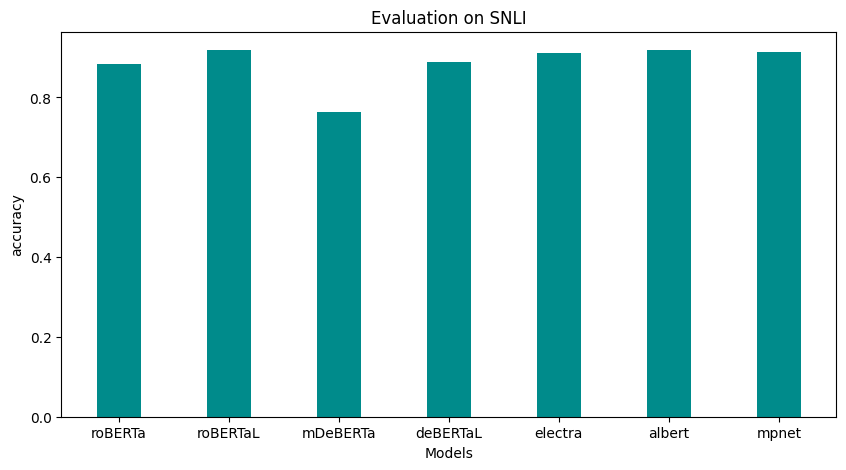

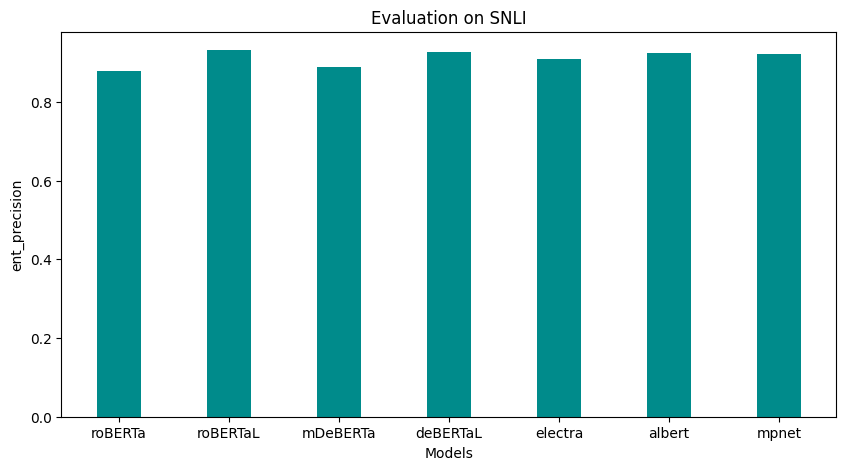

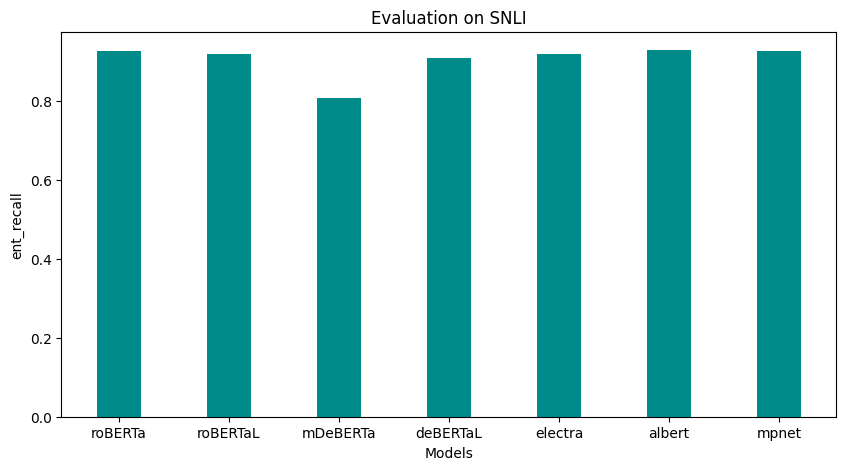

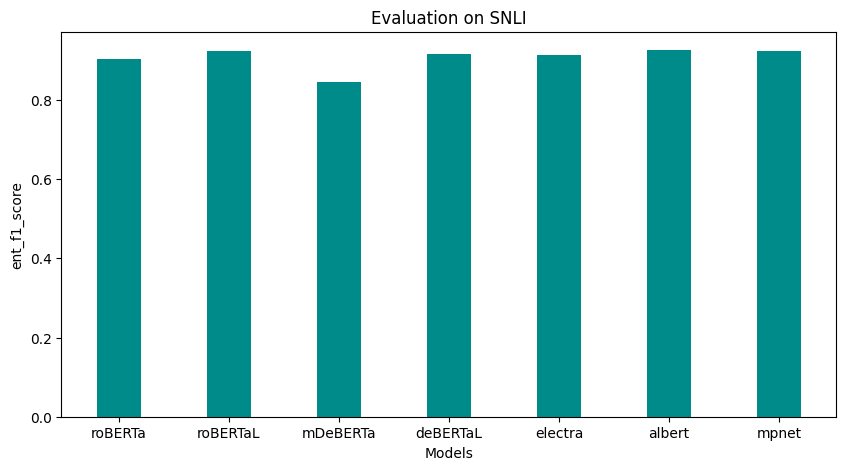

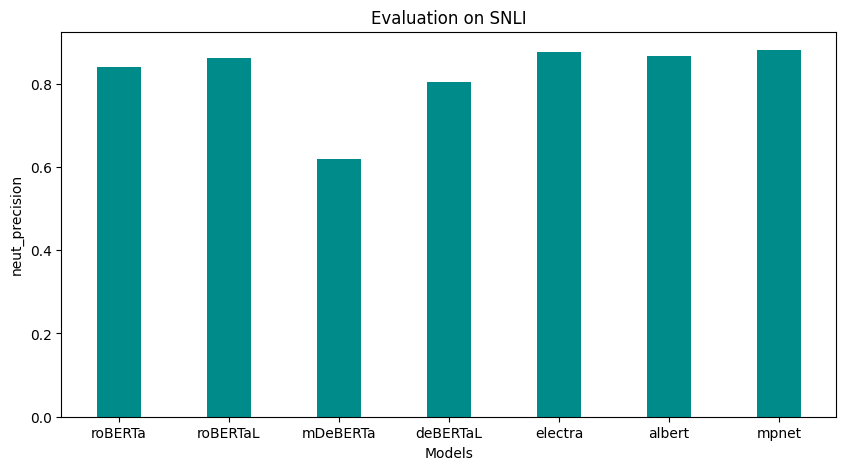

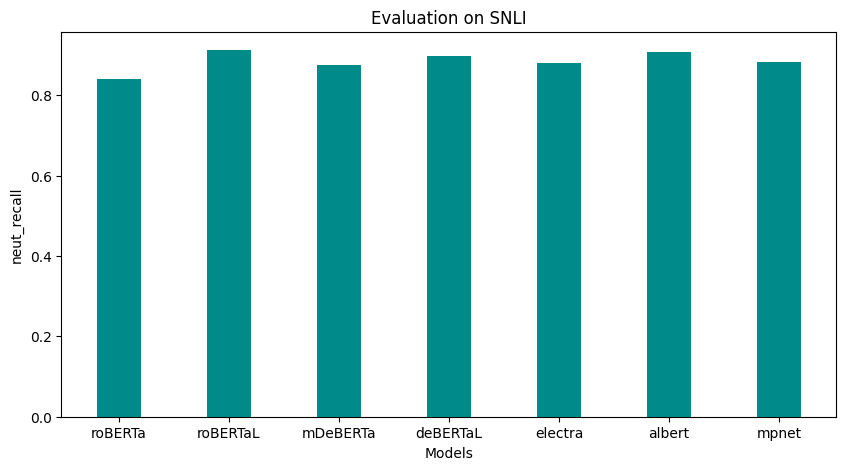

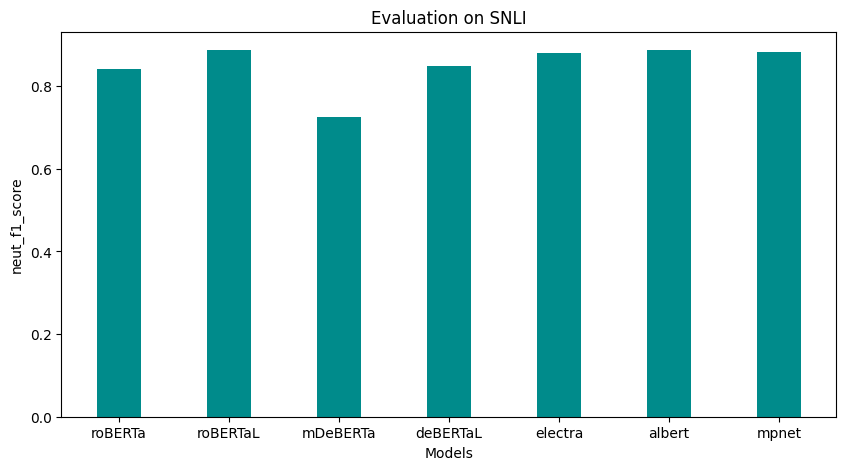

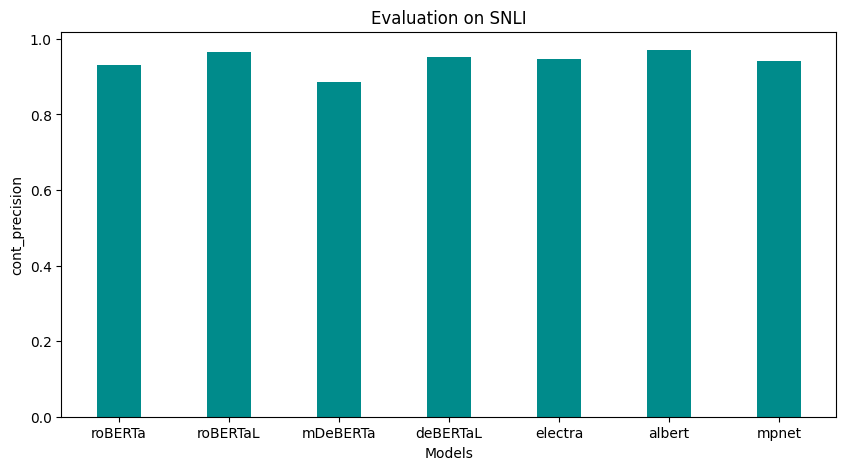

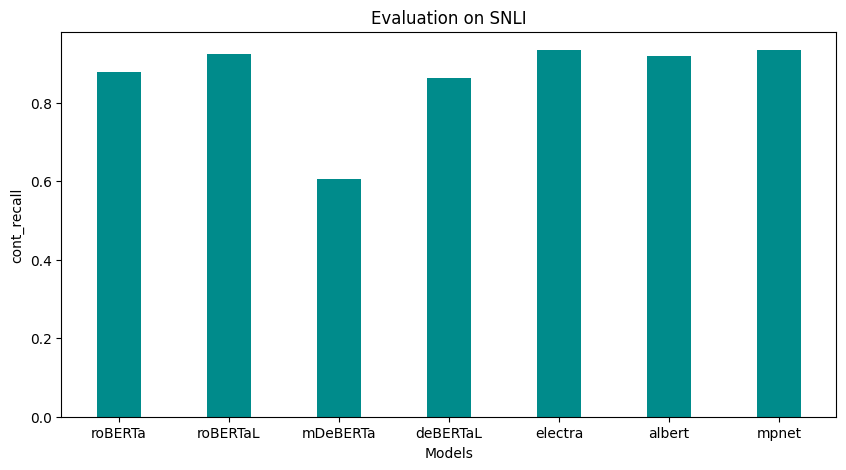

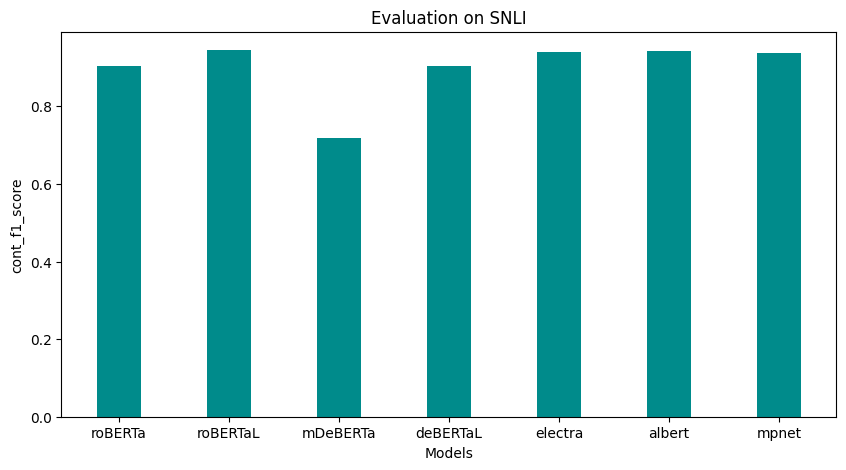

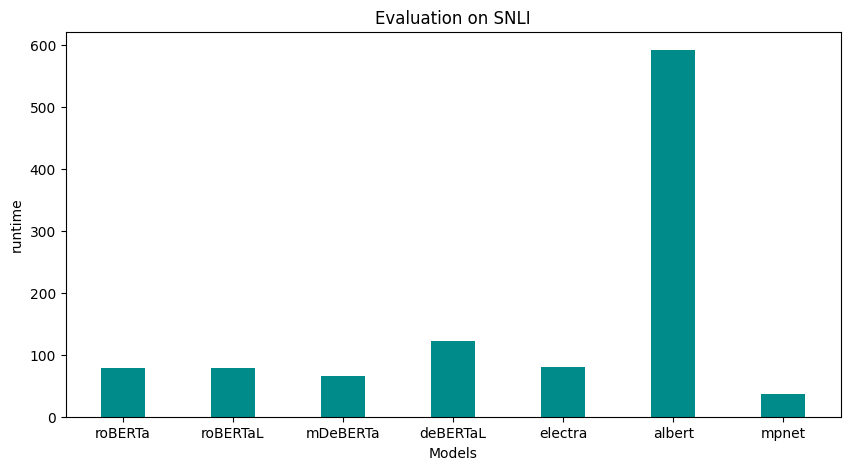

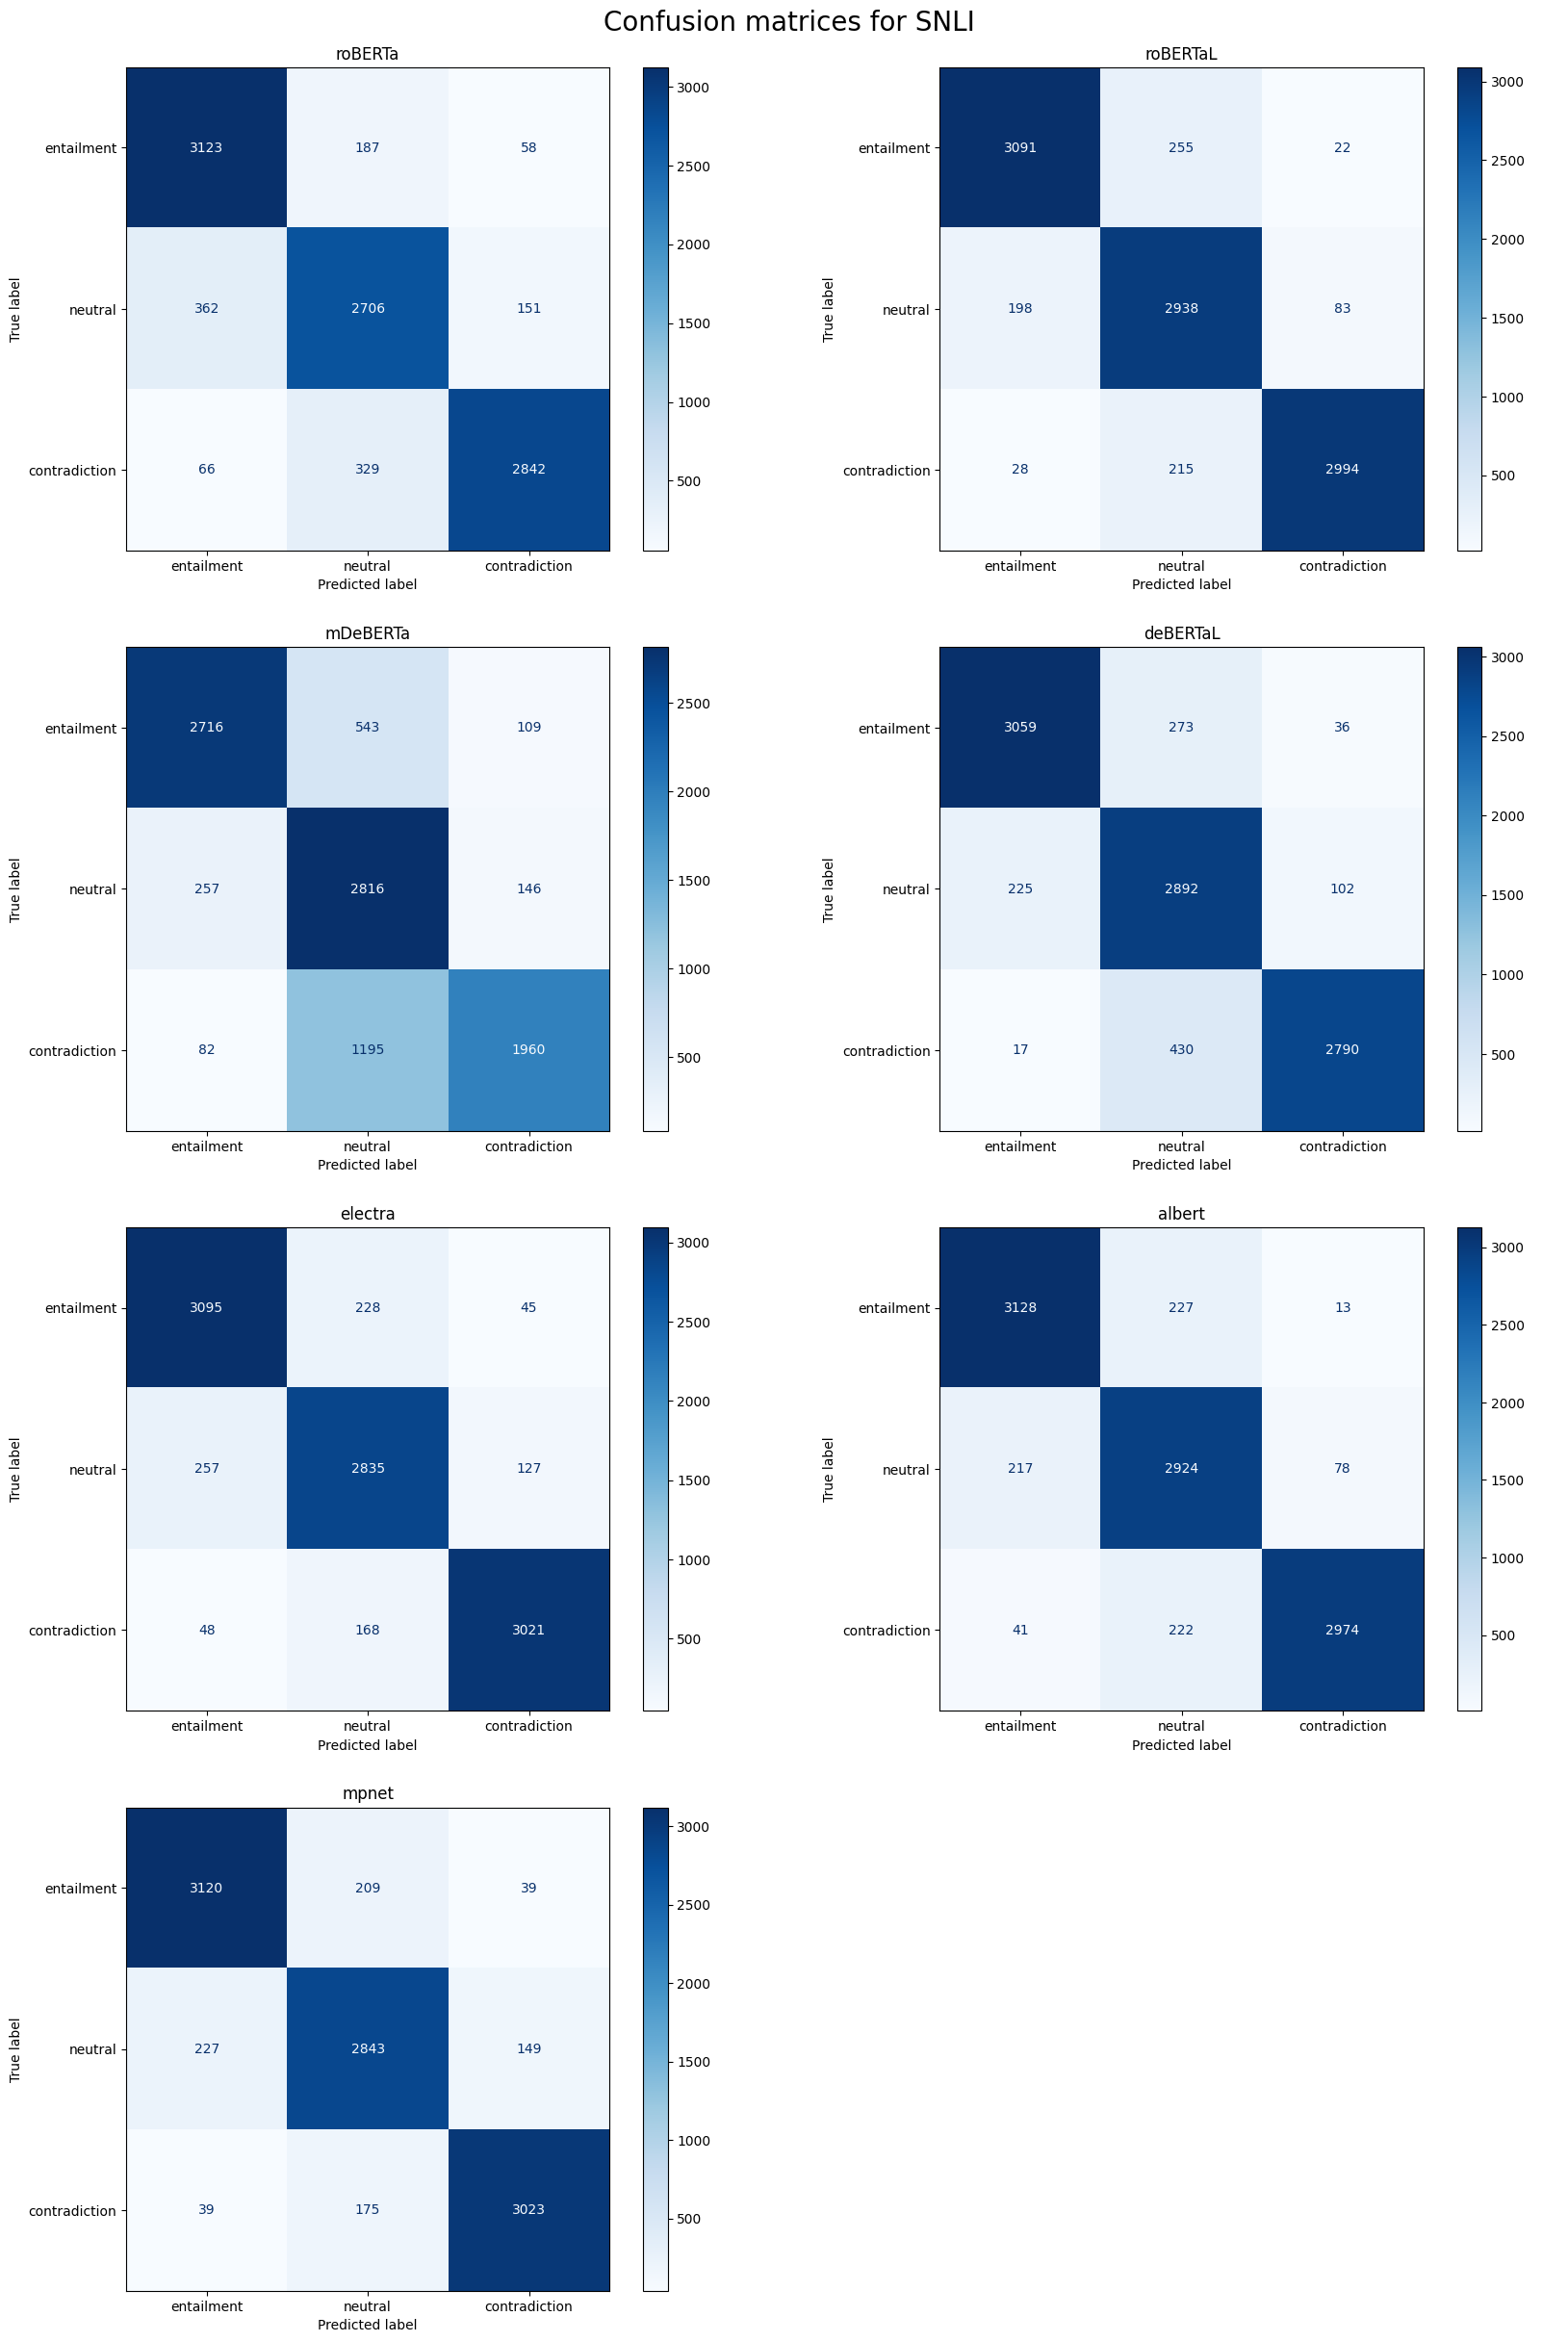

In [ ]:
printMetrics(convertToDict("SNLI-results.txt"), eval_metrics, "SNLI")

#### Discussion

In the results of the models evaluation on the SNLI dataset we can observe that all the models excluding *mDeBERTa* achieve an accuracy score of at least 80%, with the top score amounting to 91% reached by *roBERTaL*, *electra*, *albert* and *mpnet*. This can be easily explained by the fact that such models were fine-tuned on SNLI, which causes also precision, recall and f1-scores for the three labels 'entailment', 'neutral' and 'contradiction' to be high.

We note that *mDeBERTa*, which has the lower performance,
struggles most with correctly identifying 'contradiction' examples, confusing them with 'neutral' ones, as the low 'contradiction' recall and 'neutral' precision scores suggest, supported by the confusion matrix.

As for evaluation running time, *albert* distinguished itself by taking about 10 minutes to classify the SNLI examples.


### MNLI results

#### Plots

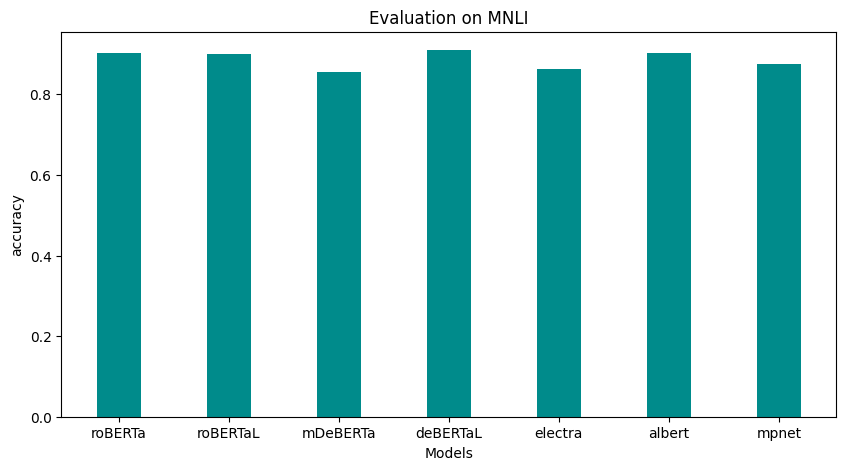

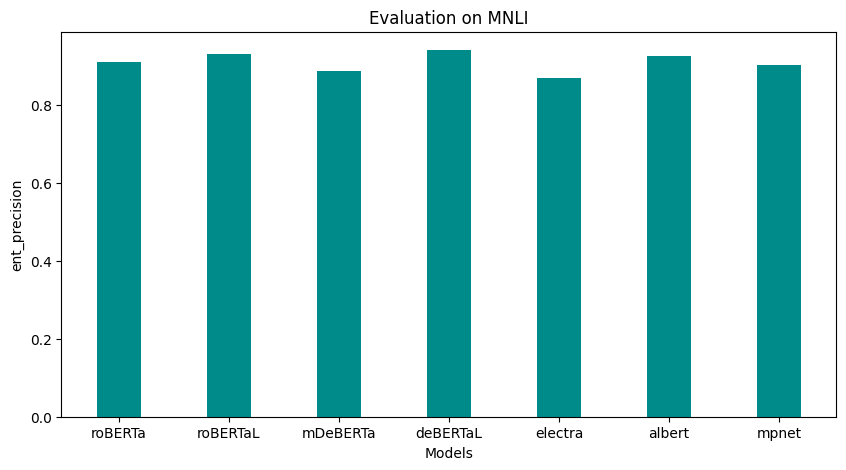

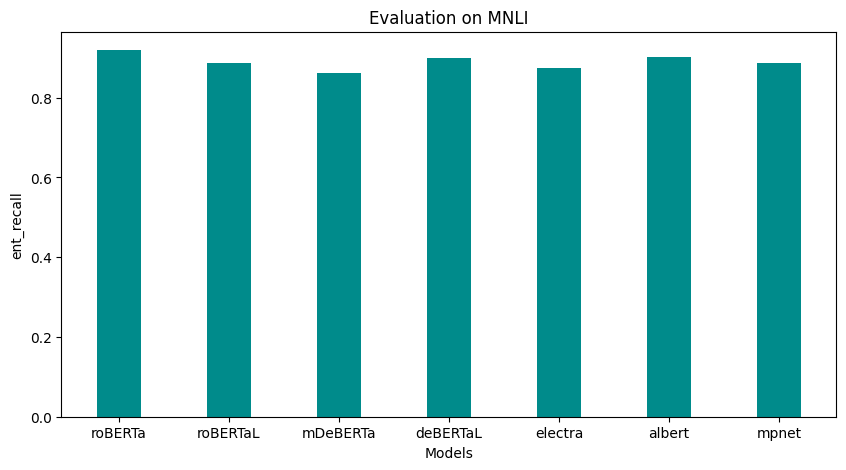

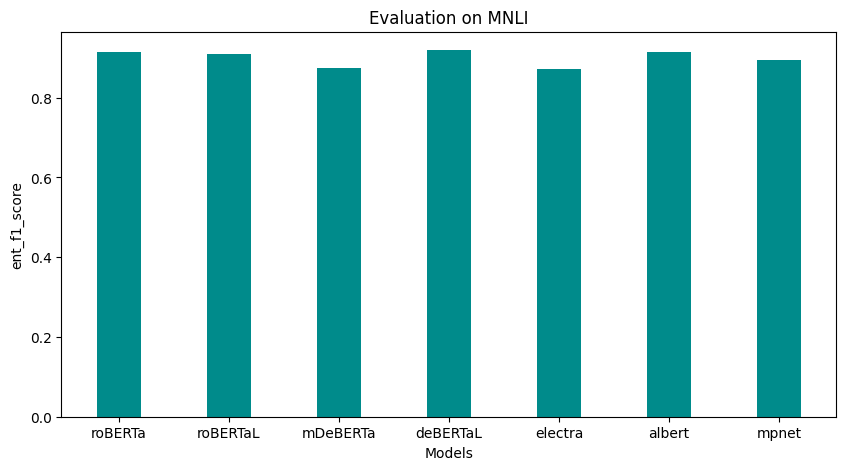

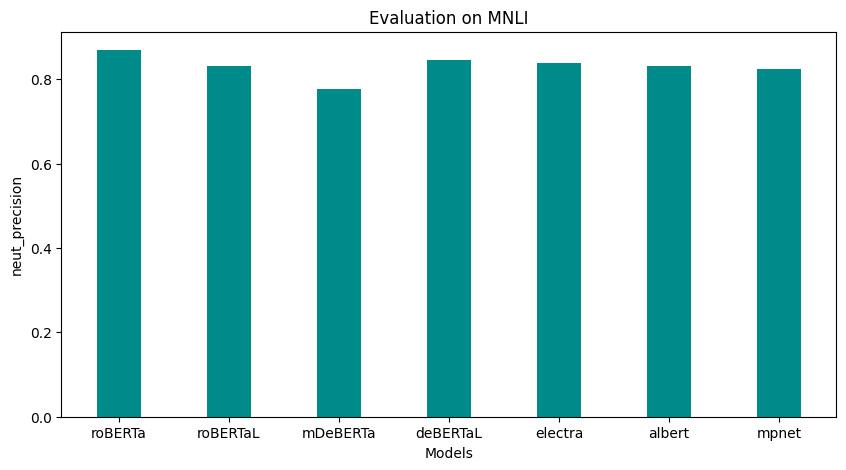

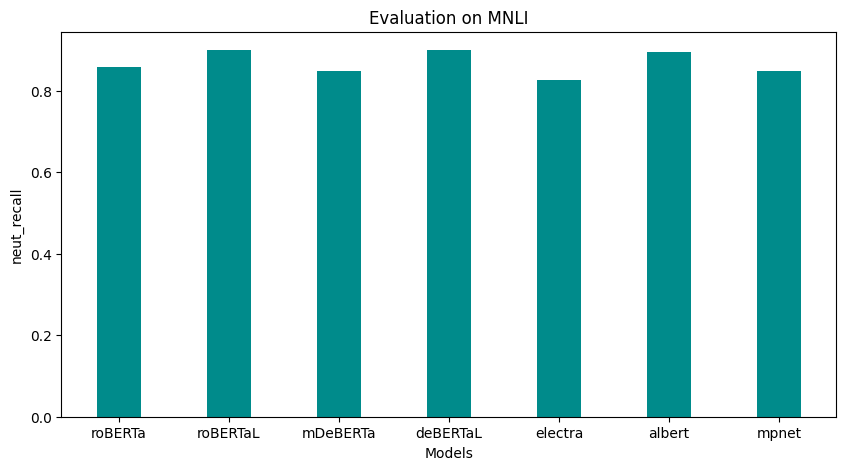

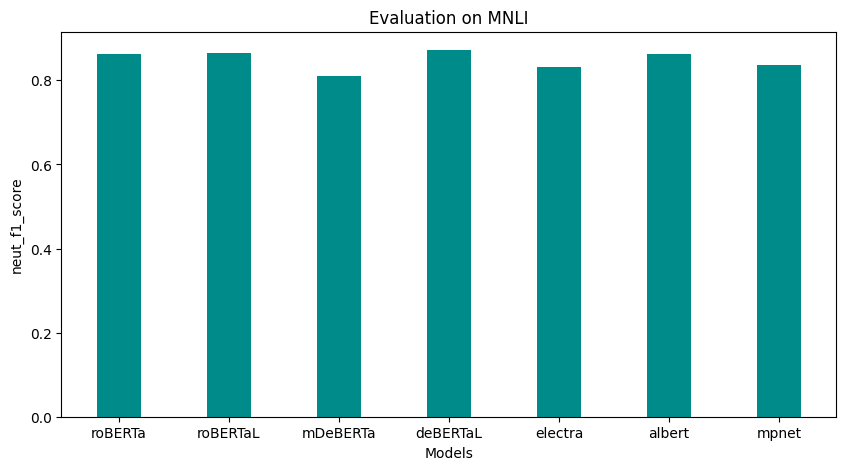

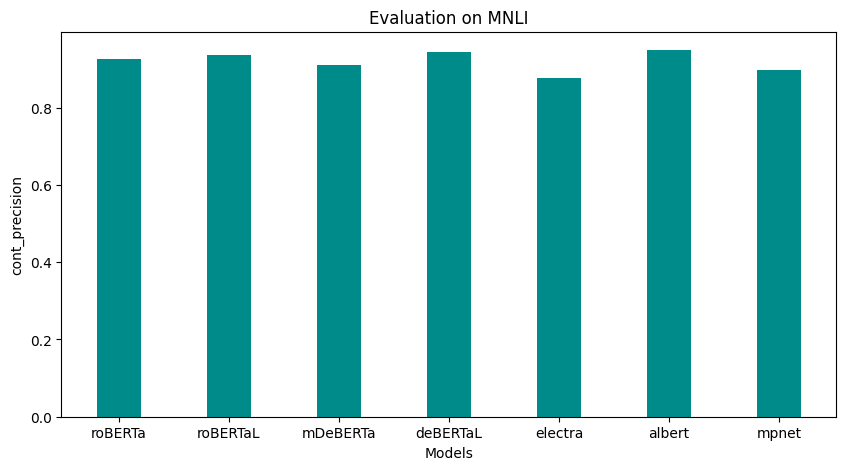

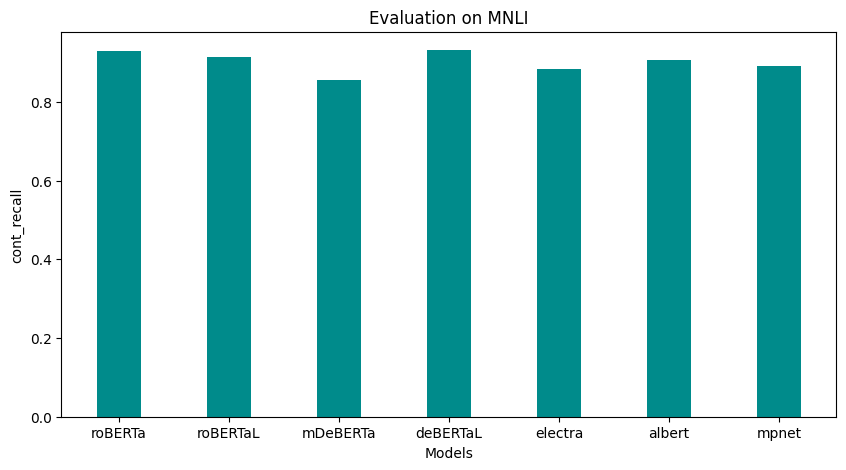

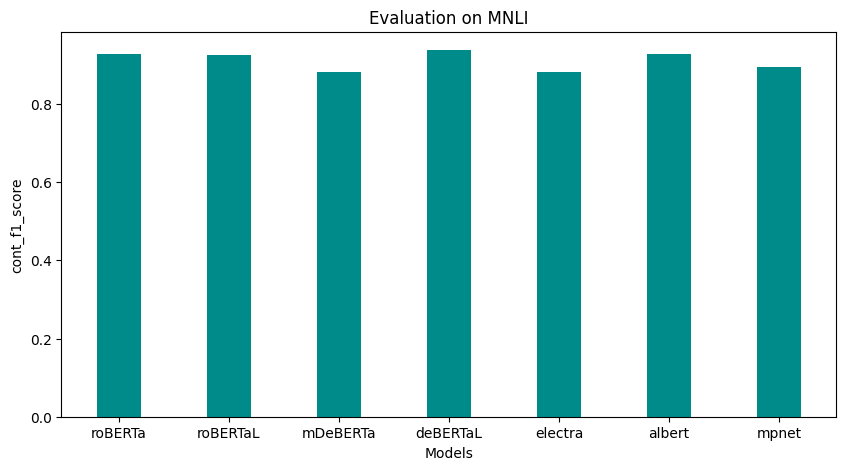

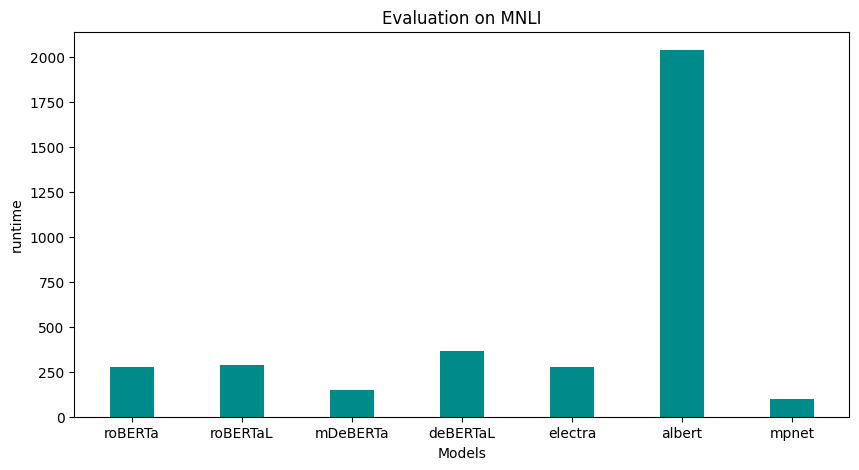

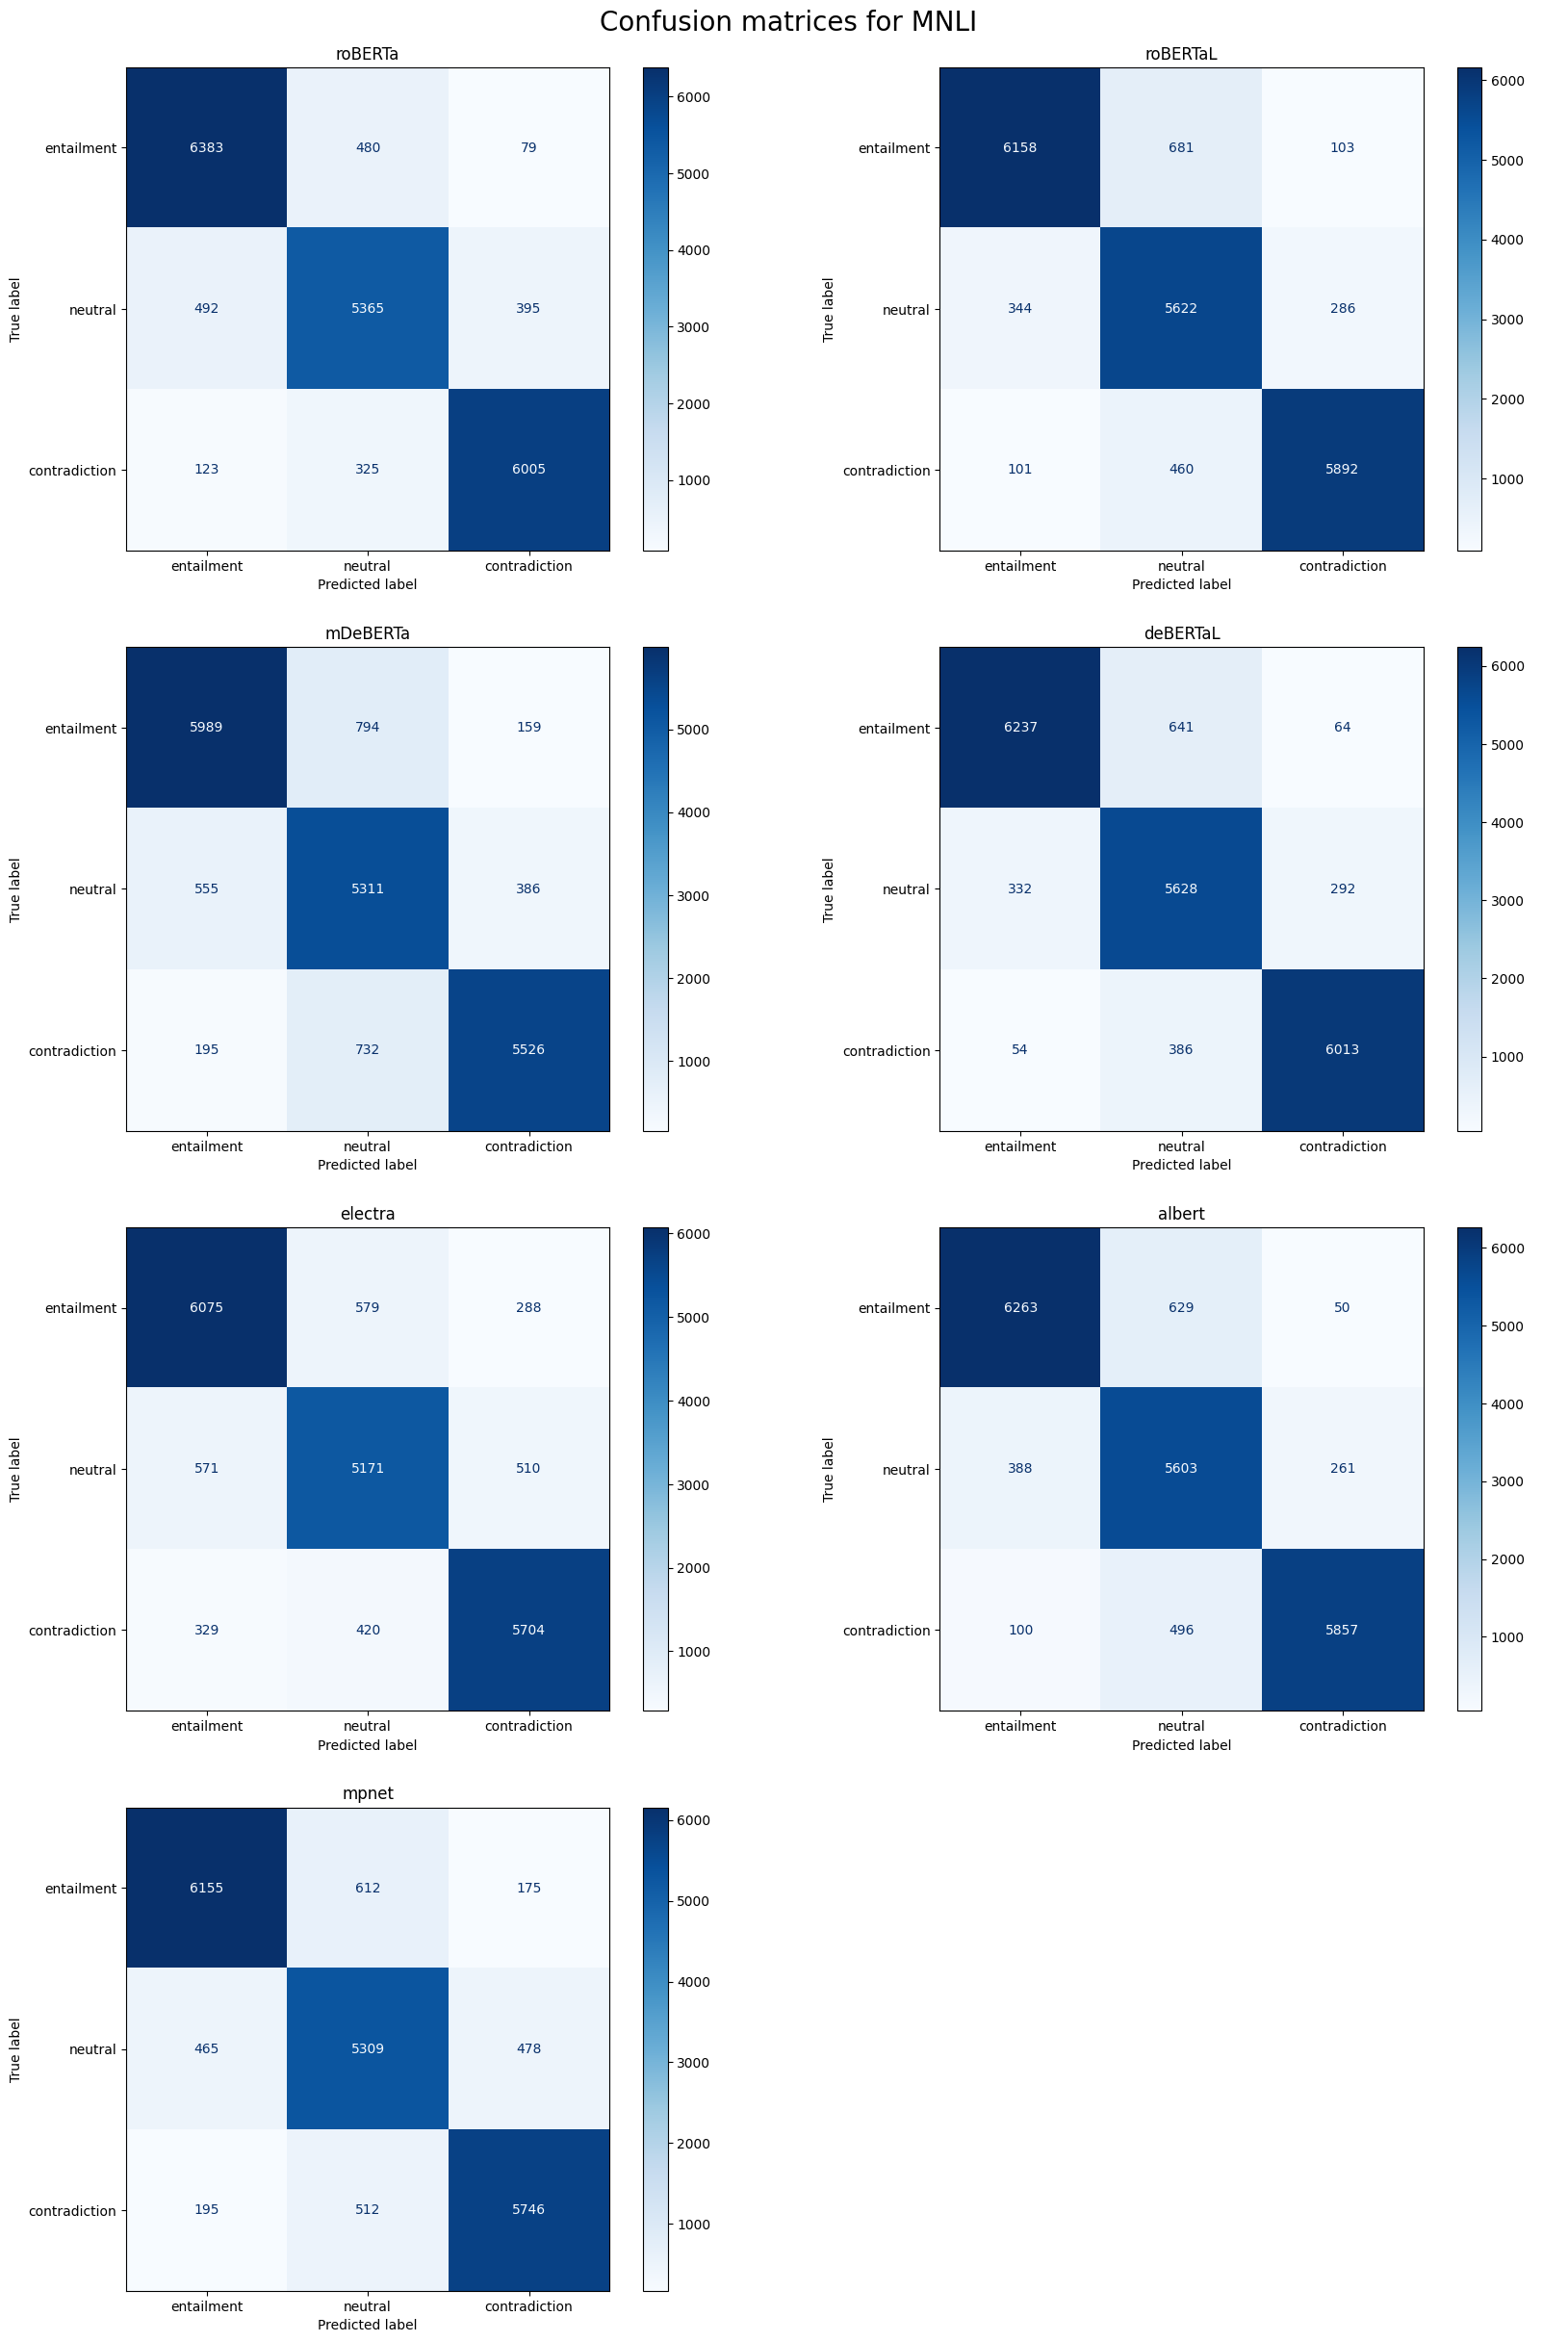

In [ ]:
printMetrics(convertToDict("MNLI-results.txt"), eval_metrics, "MNLI")

#### Discussion

Since all of the models were fine-tuned in some way on the MNLI dataset, they perform almost equally well, keeping close to an accuracy score of 90%. From the confusion matrices we note that, as could be expected, the 'neutral' examples are the ones that get confused the most with the others.

Similarly to what observed regarding evaluation running time on SNLI, *albert* took much longer than the other models to classify the examples (about 30 minutes, compared to at most 5 minutes for the other running times).

### ANLI results

#### Plots

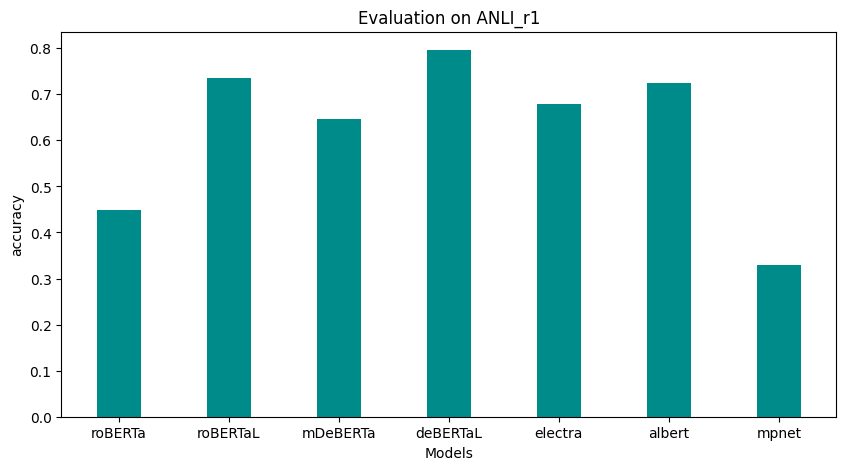

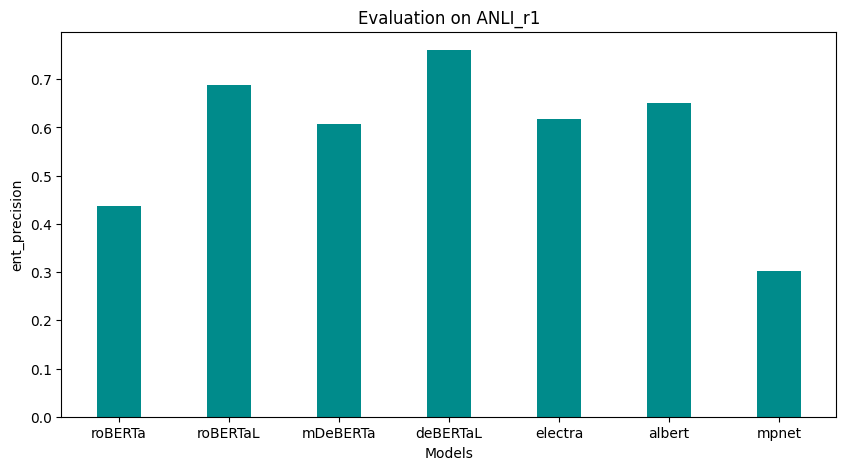

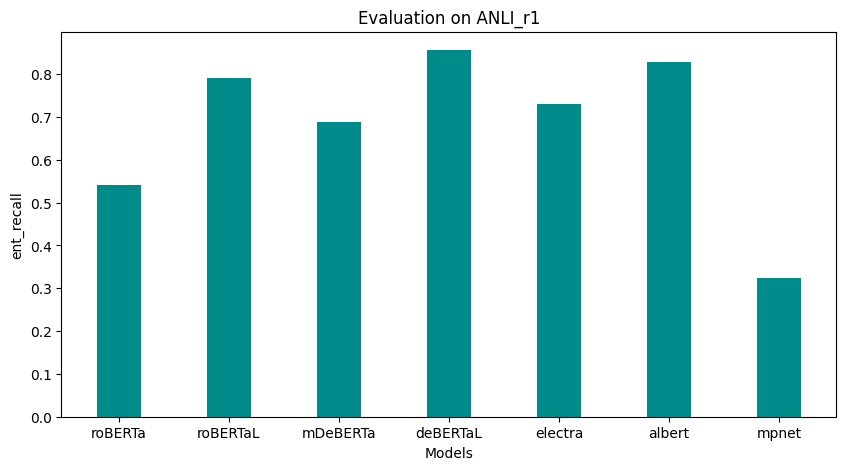

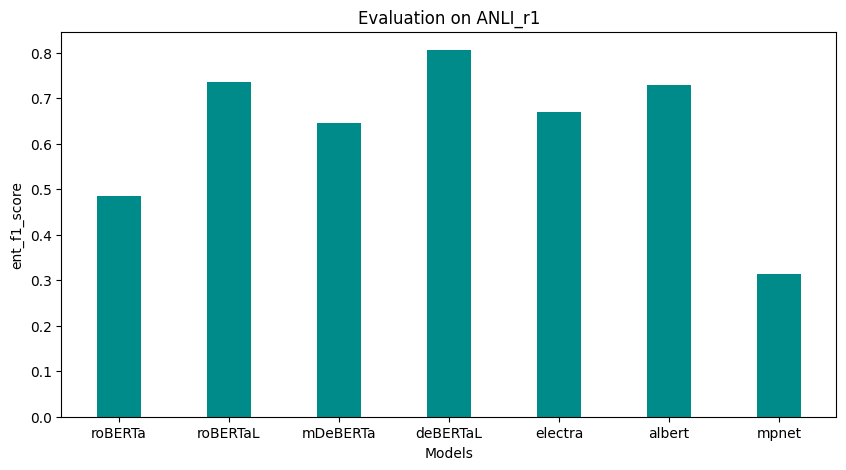

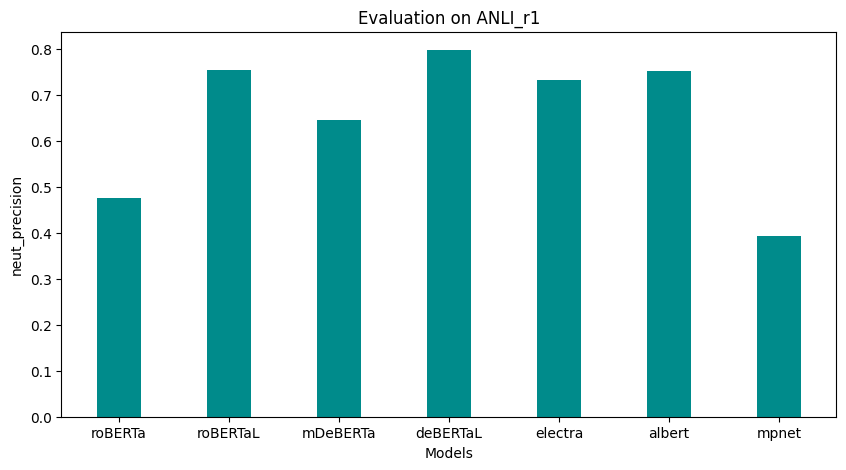

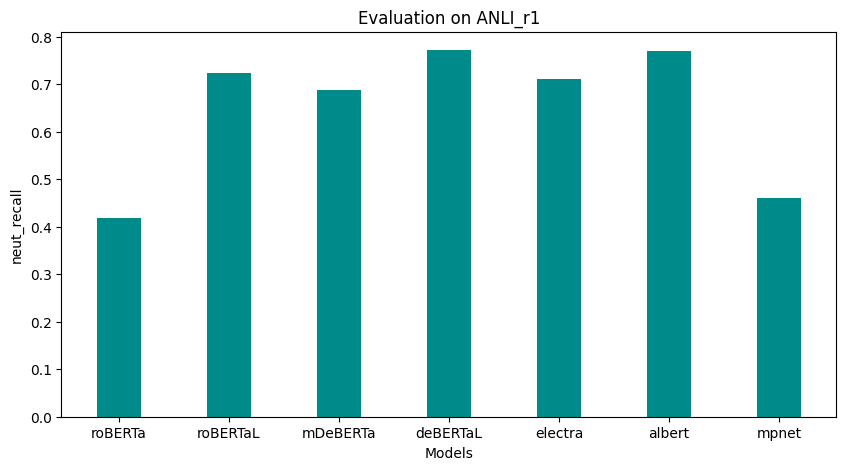

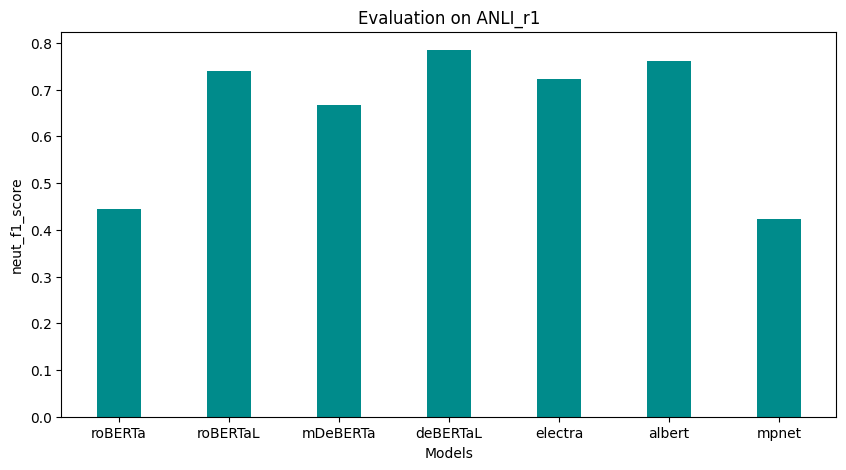

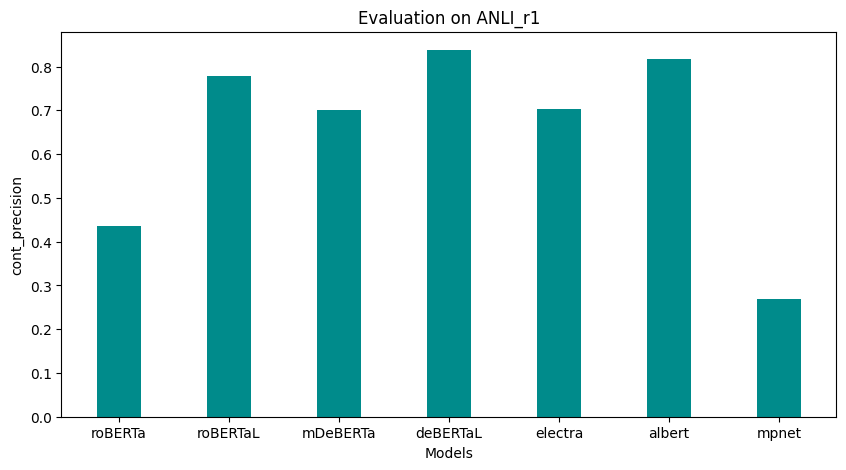

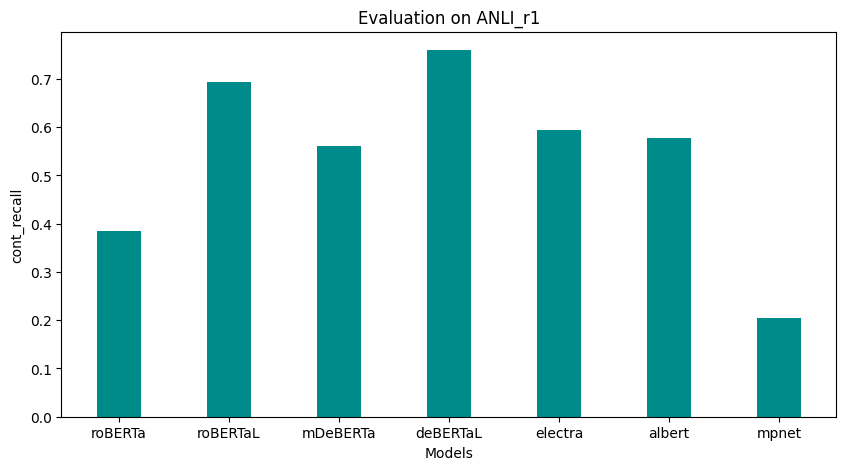

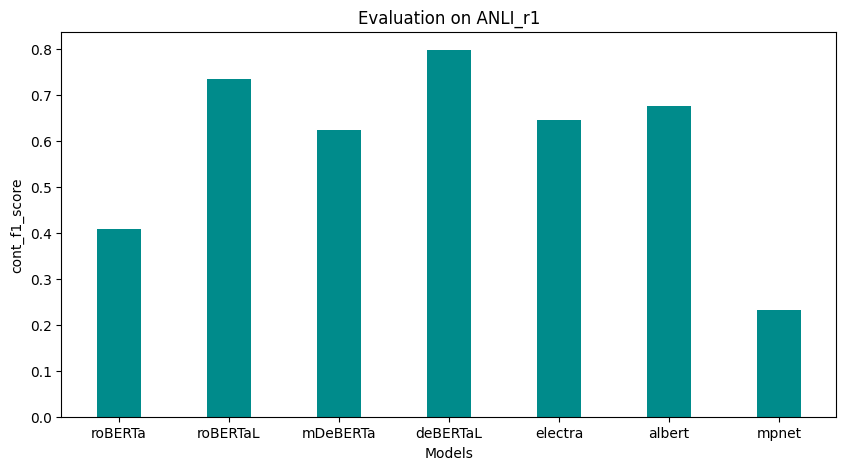

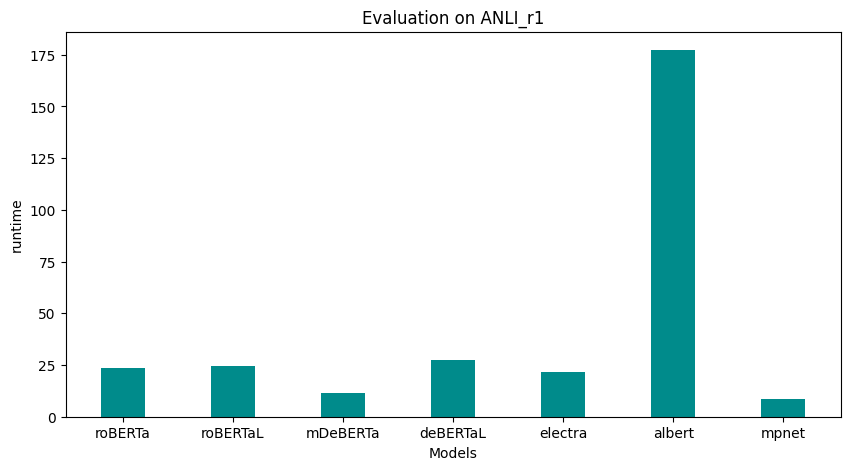

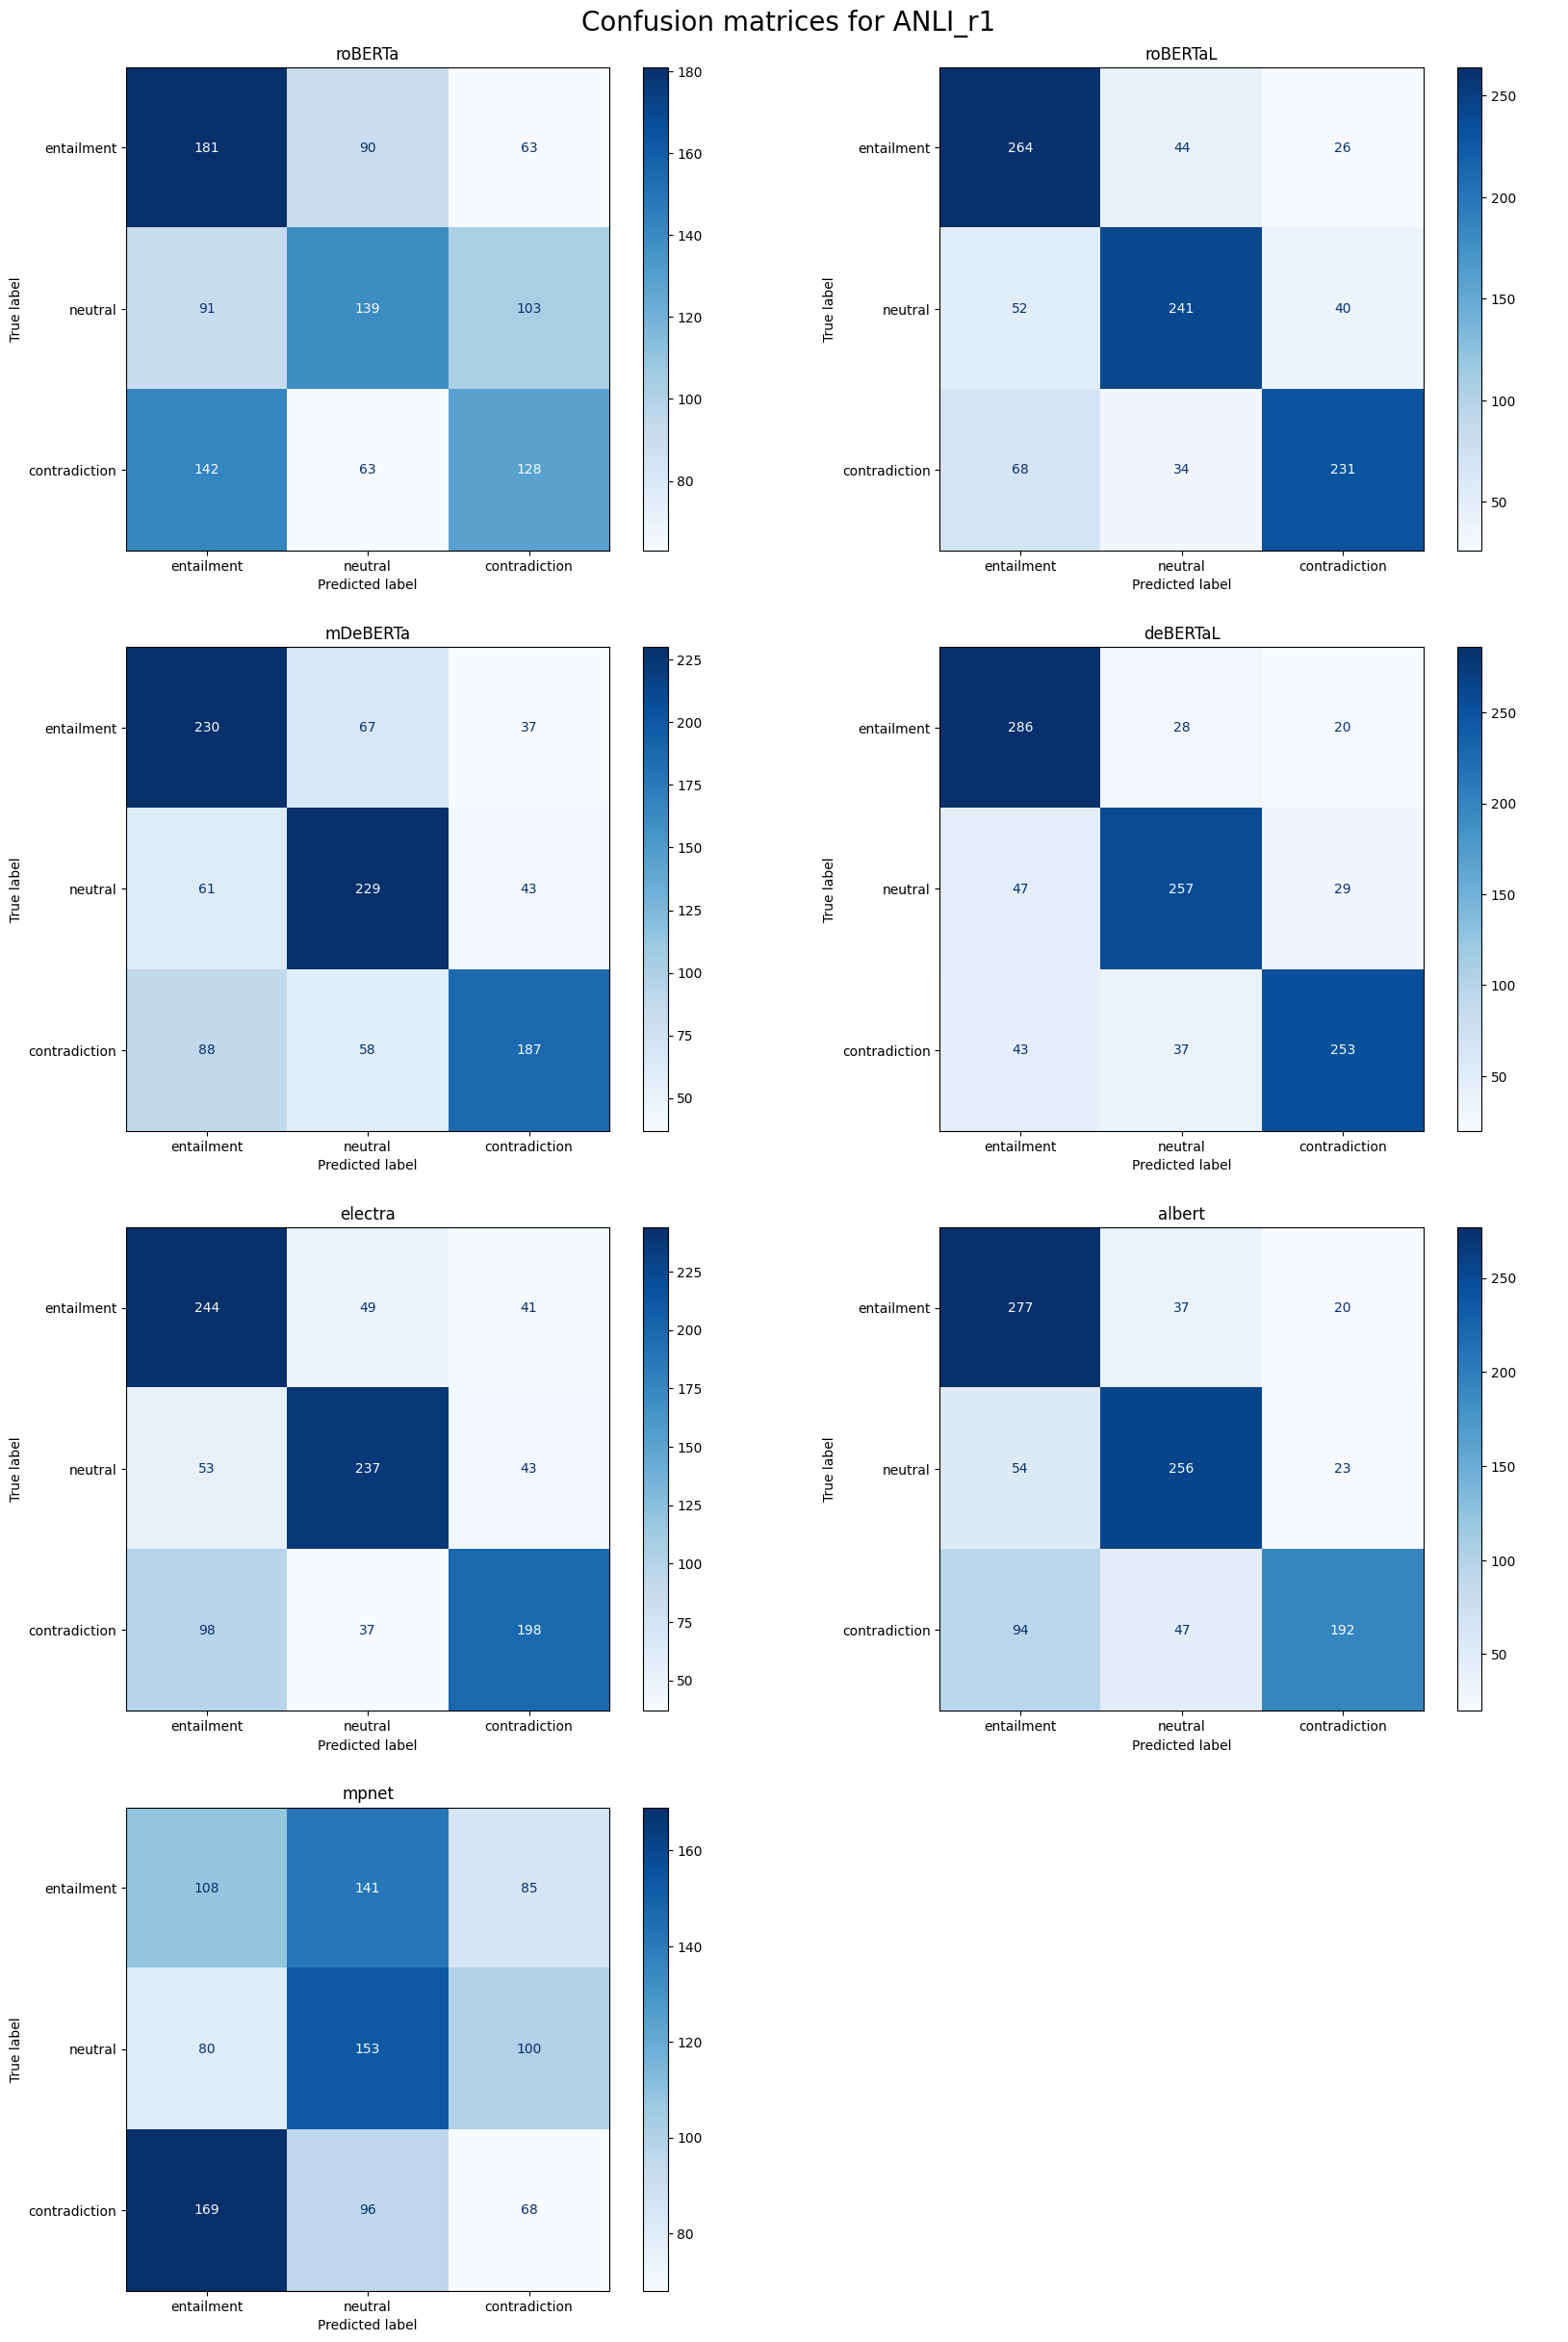

In [ ]:
printMetrics(convertToDict("ANLI_r1-results.txt"), eval_metrics, "ANLI_r1")

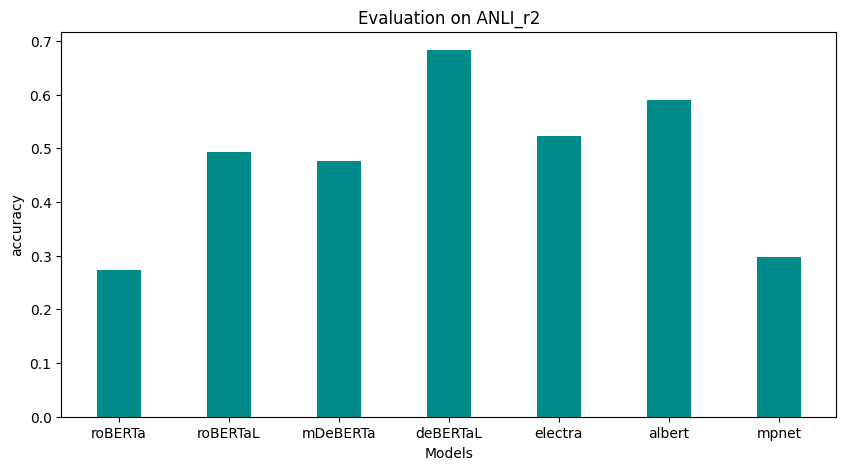

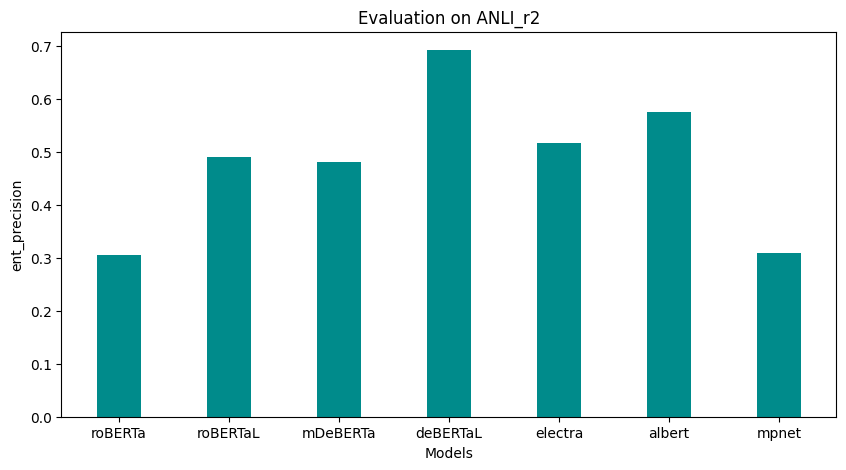

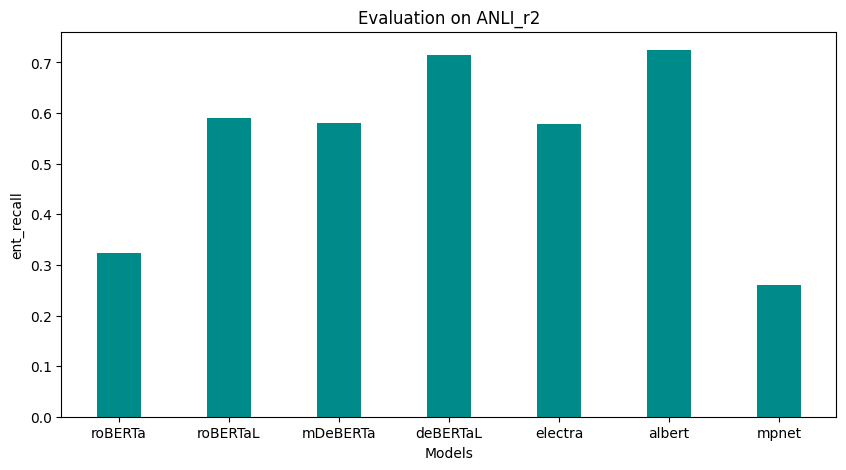

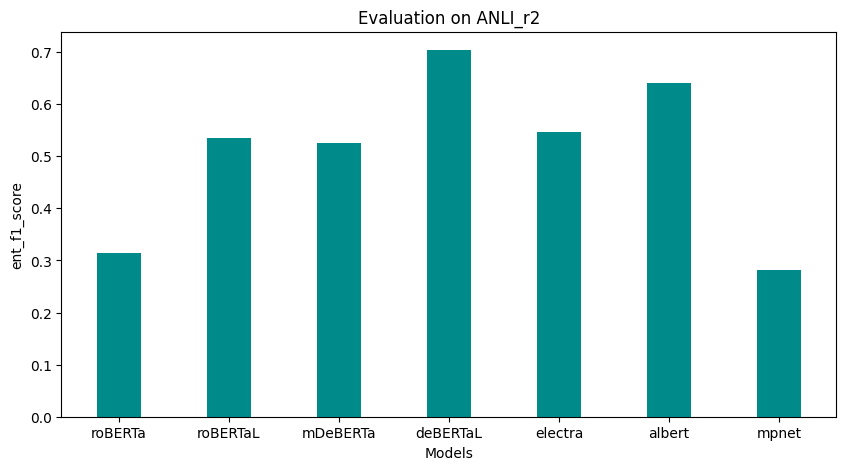

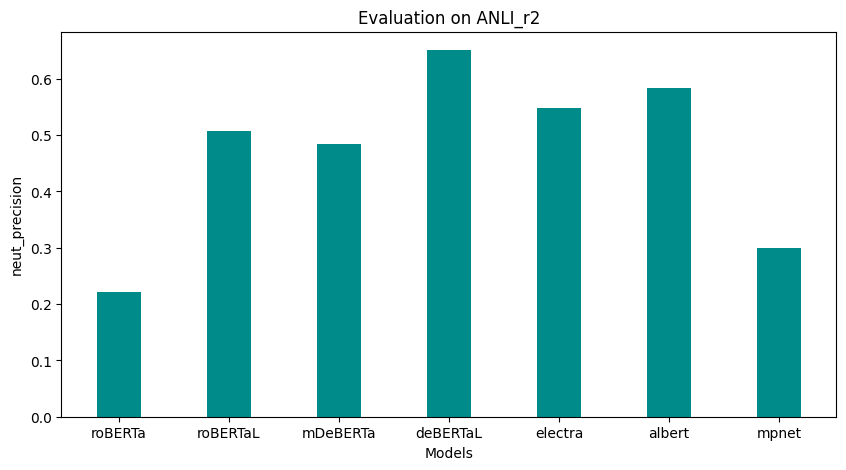

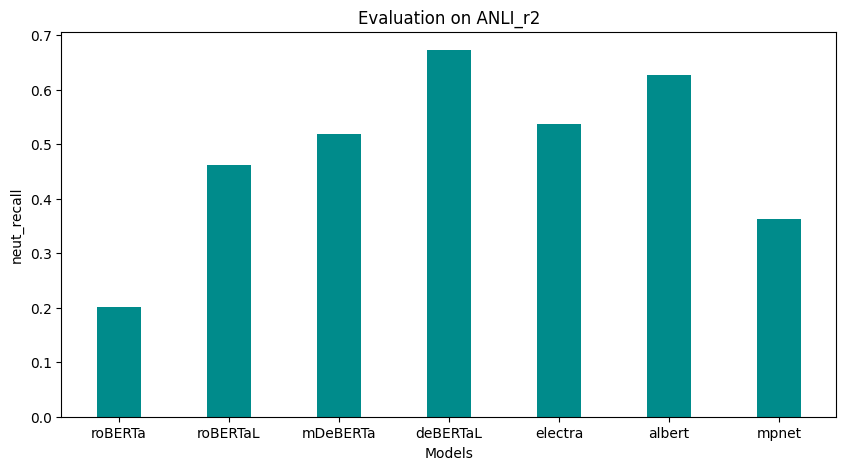

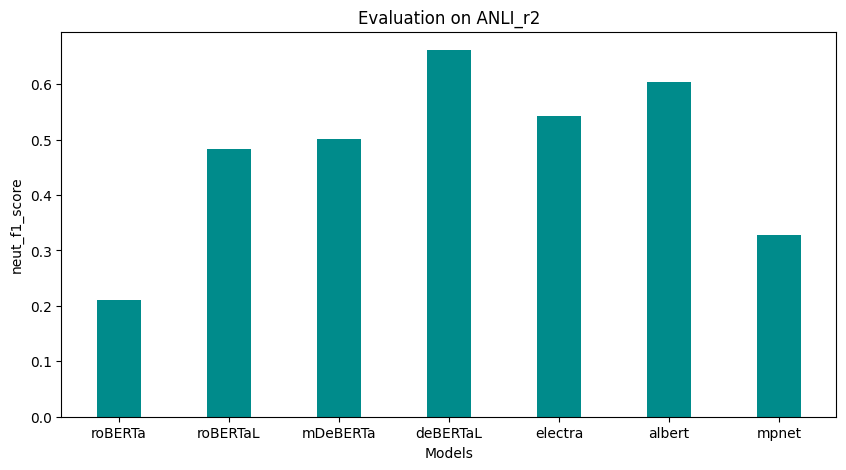

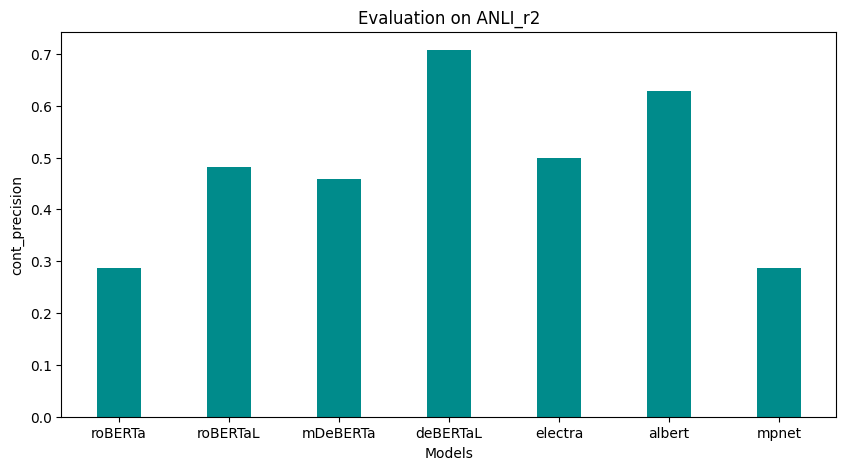

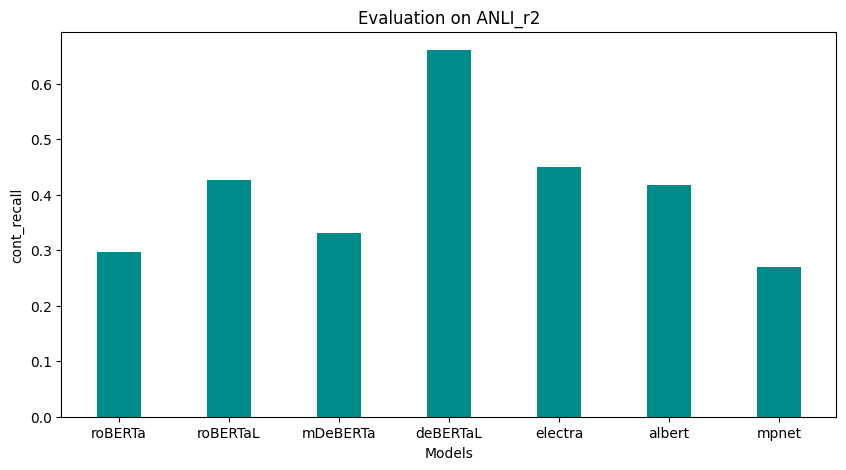

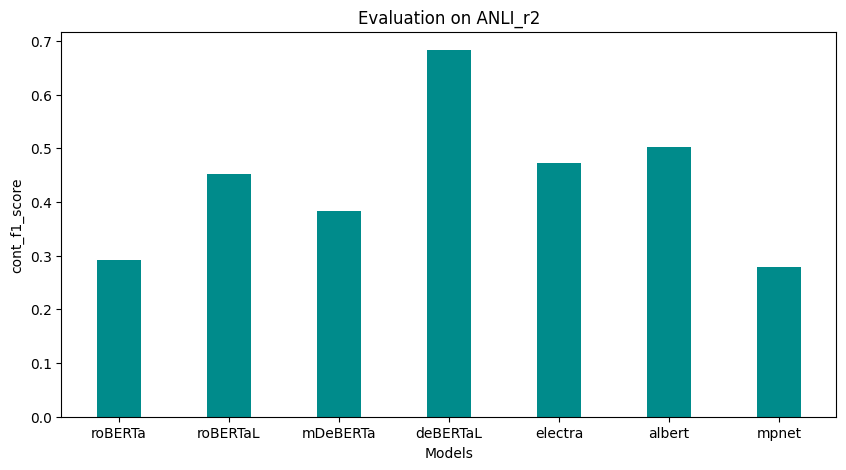

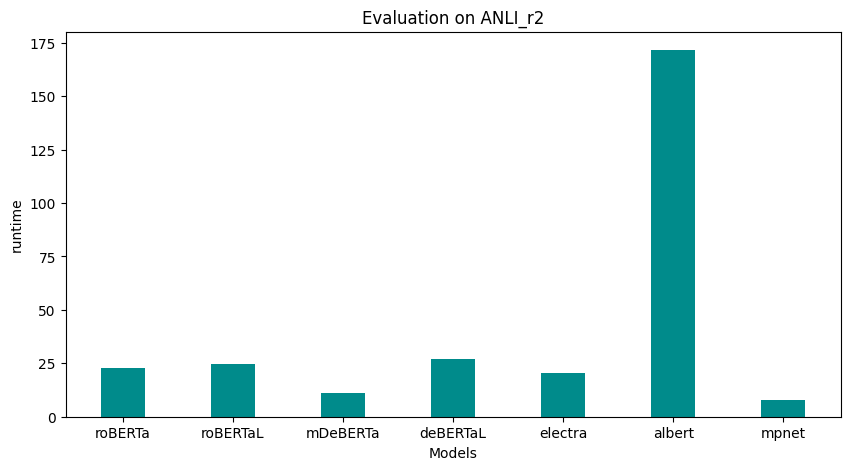

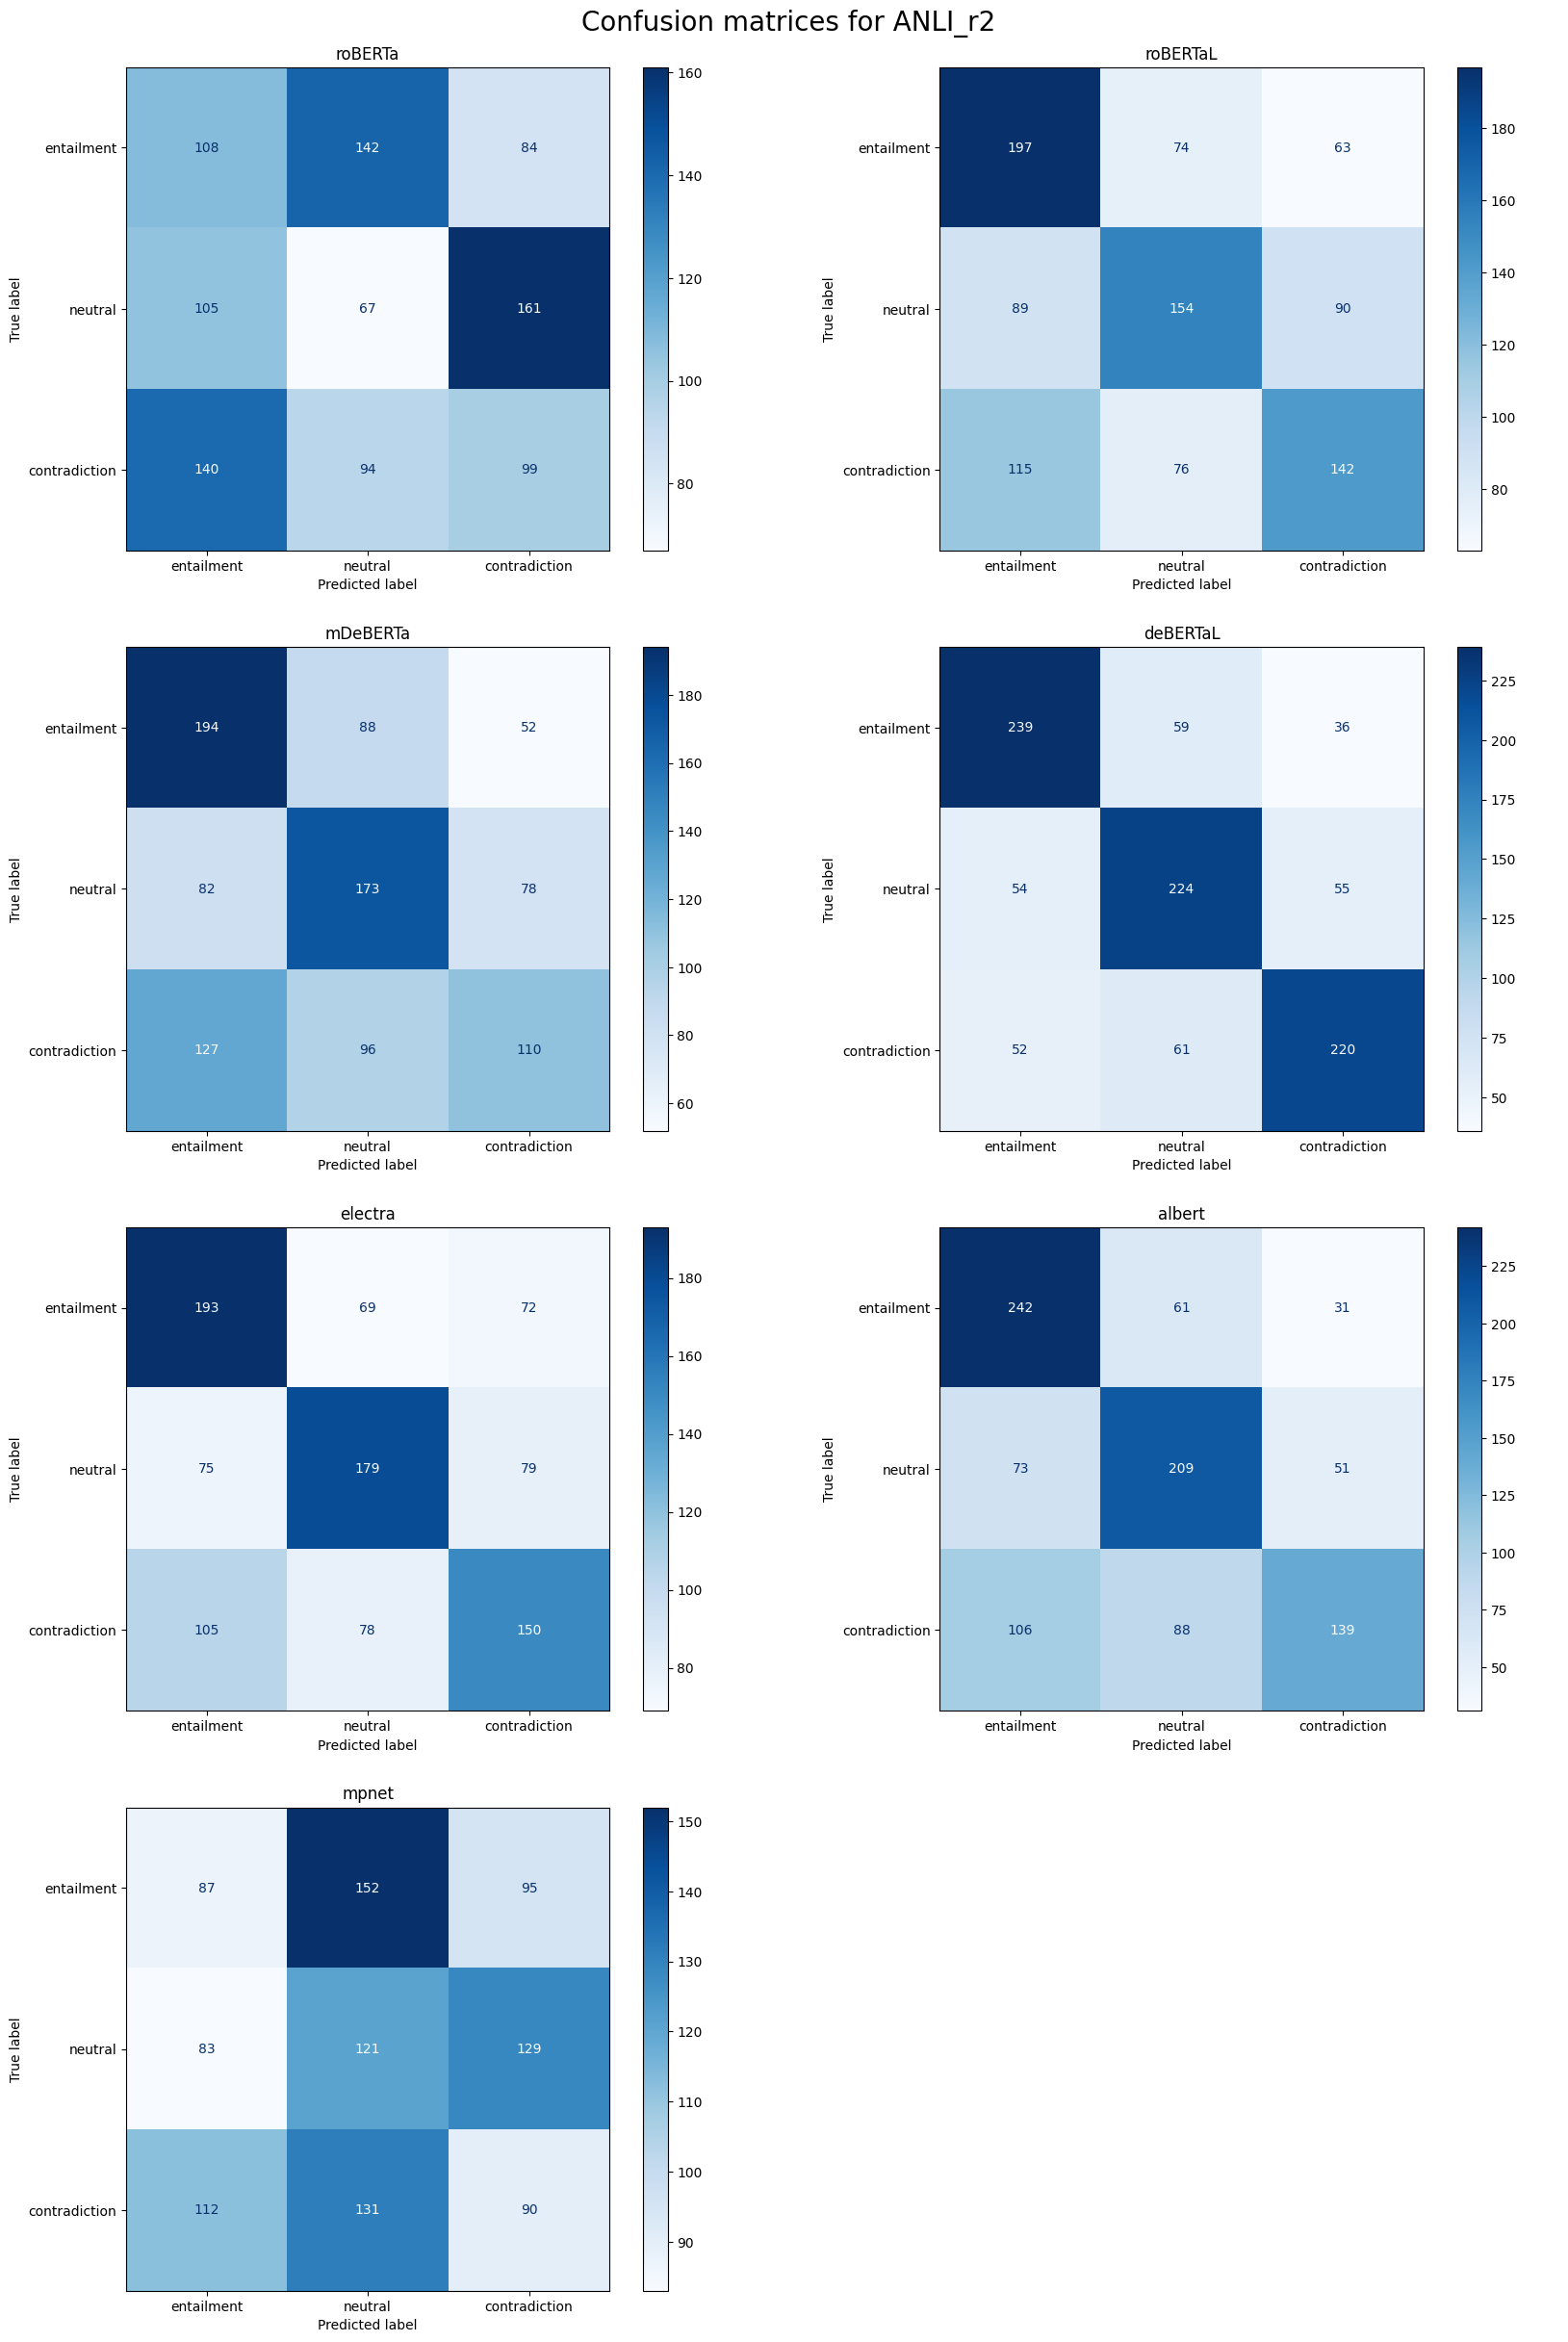

In [ ]:
printMetrics(convertToDict("ANLI_r2-results.txt"), eval_metrics, "ANLI_r2")

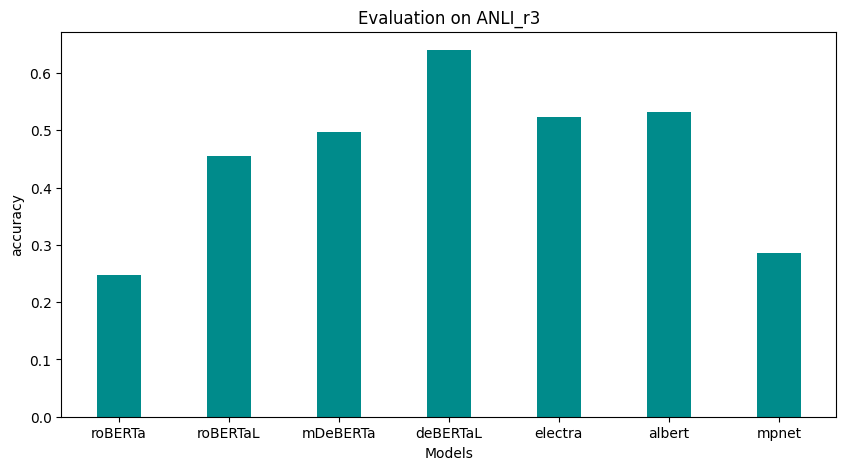

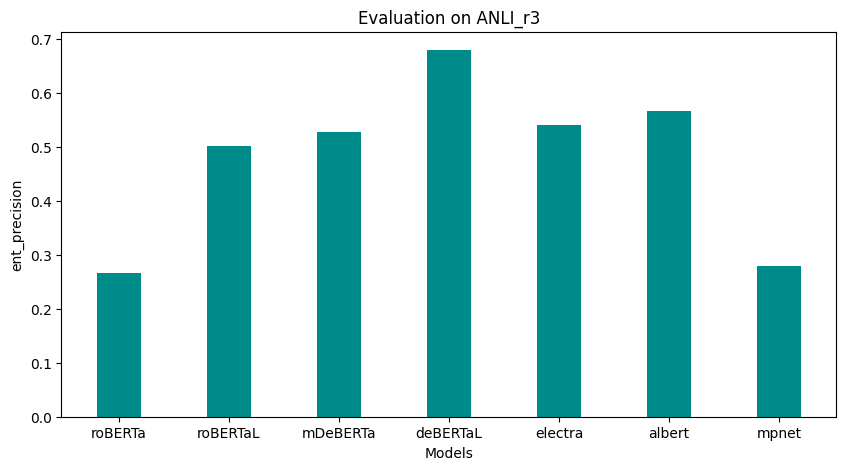

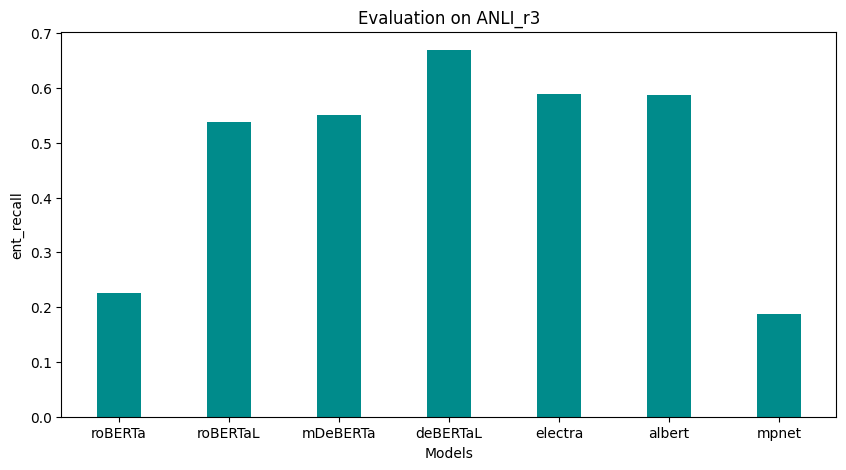

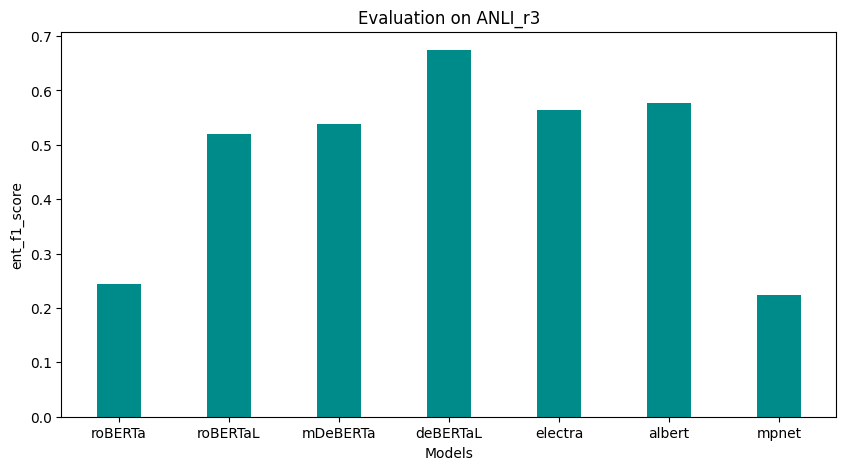

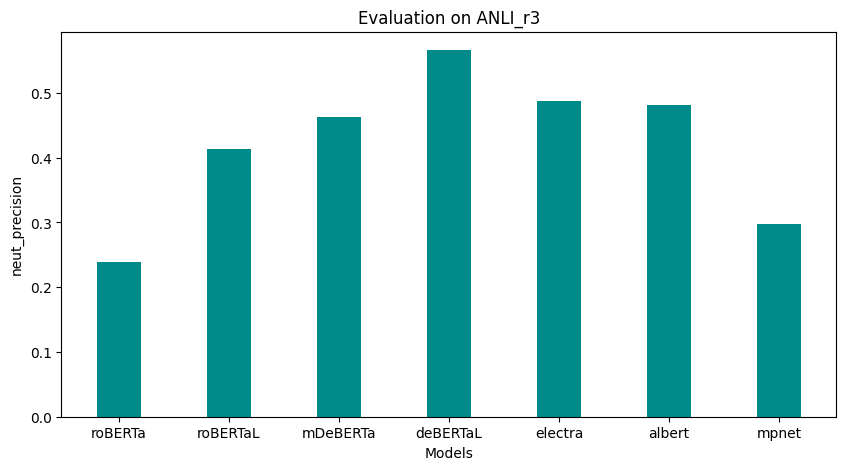

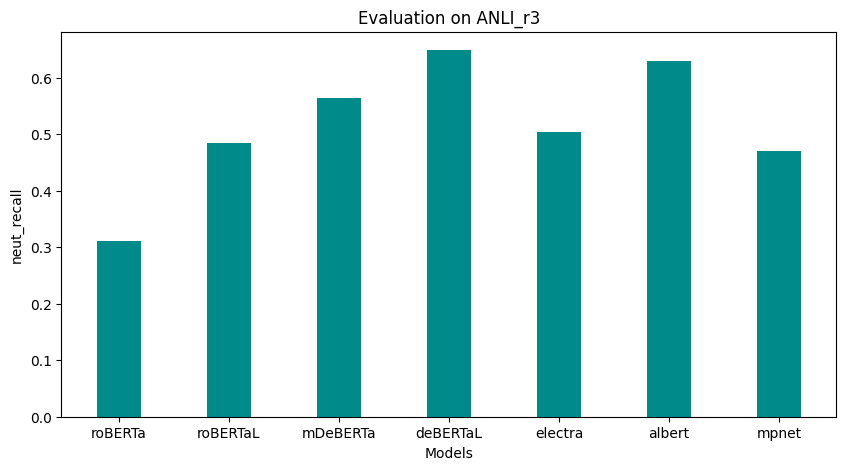

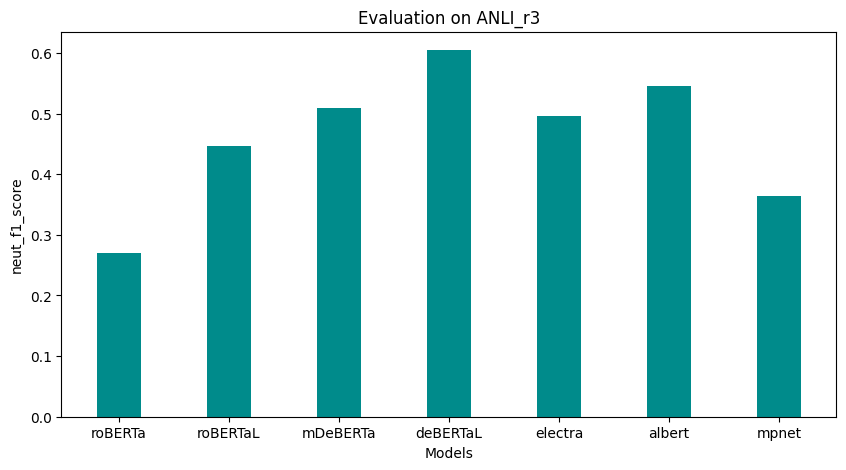

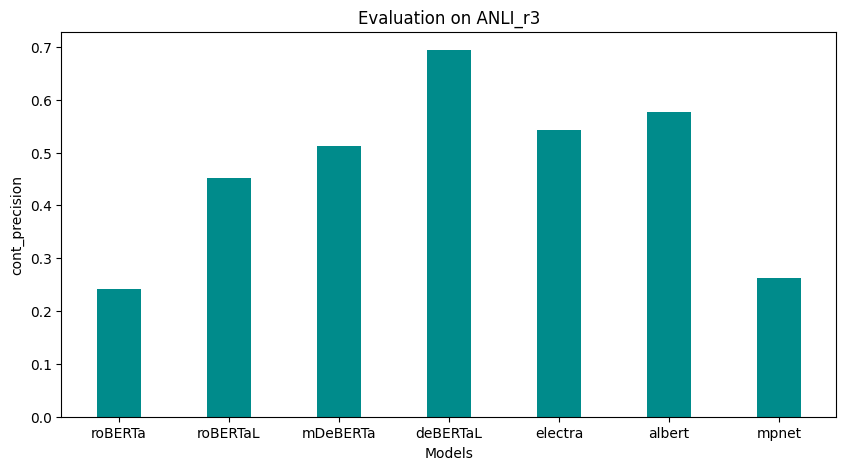

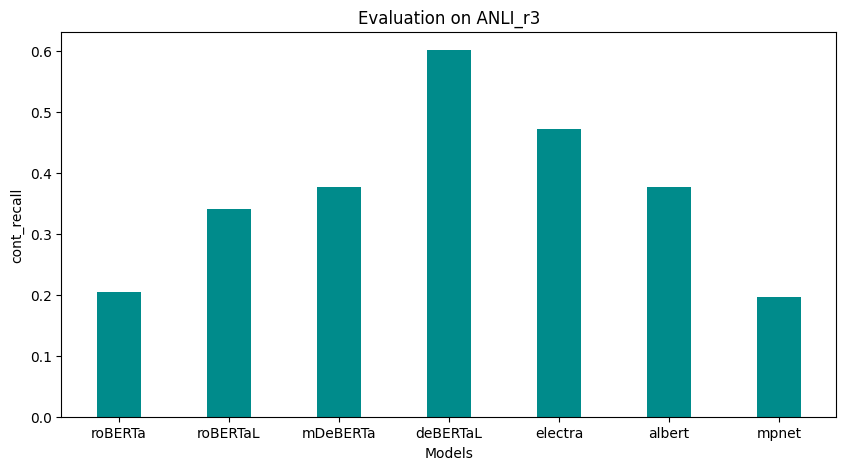

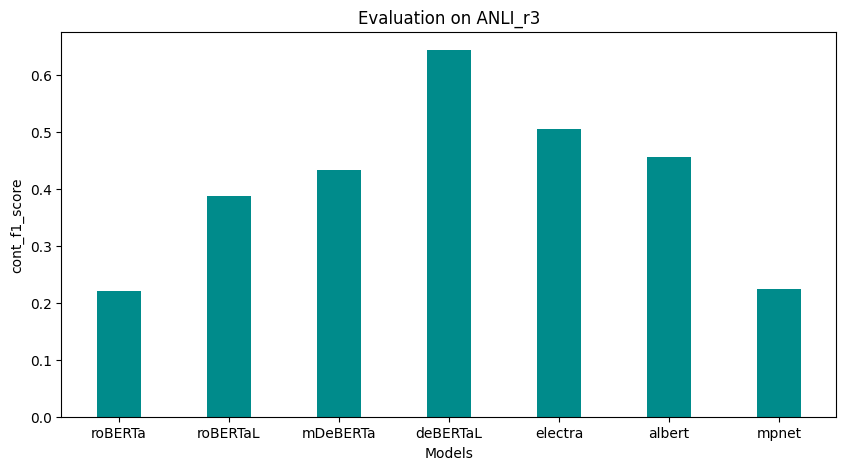

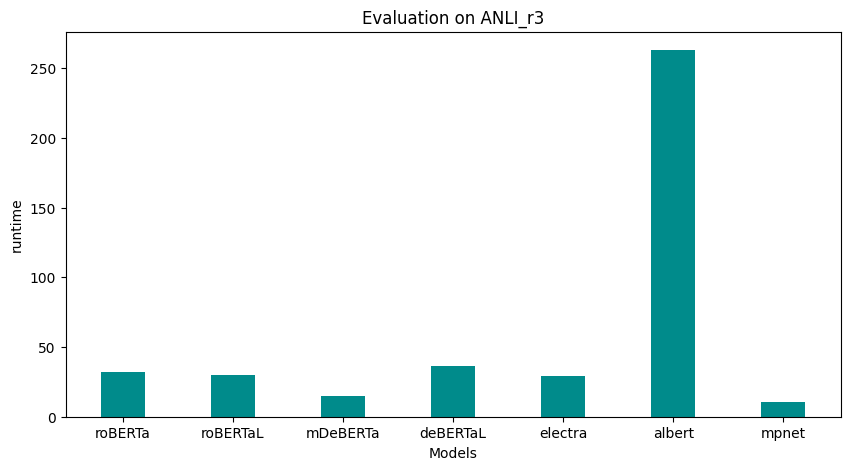

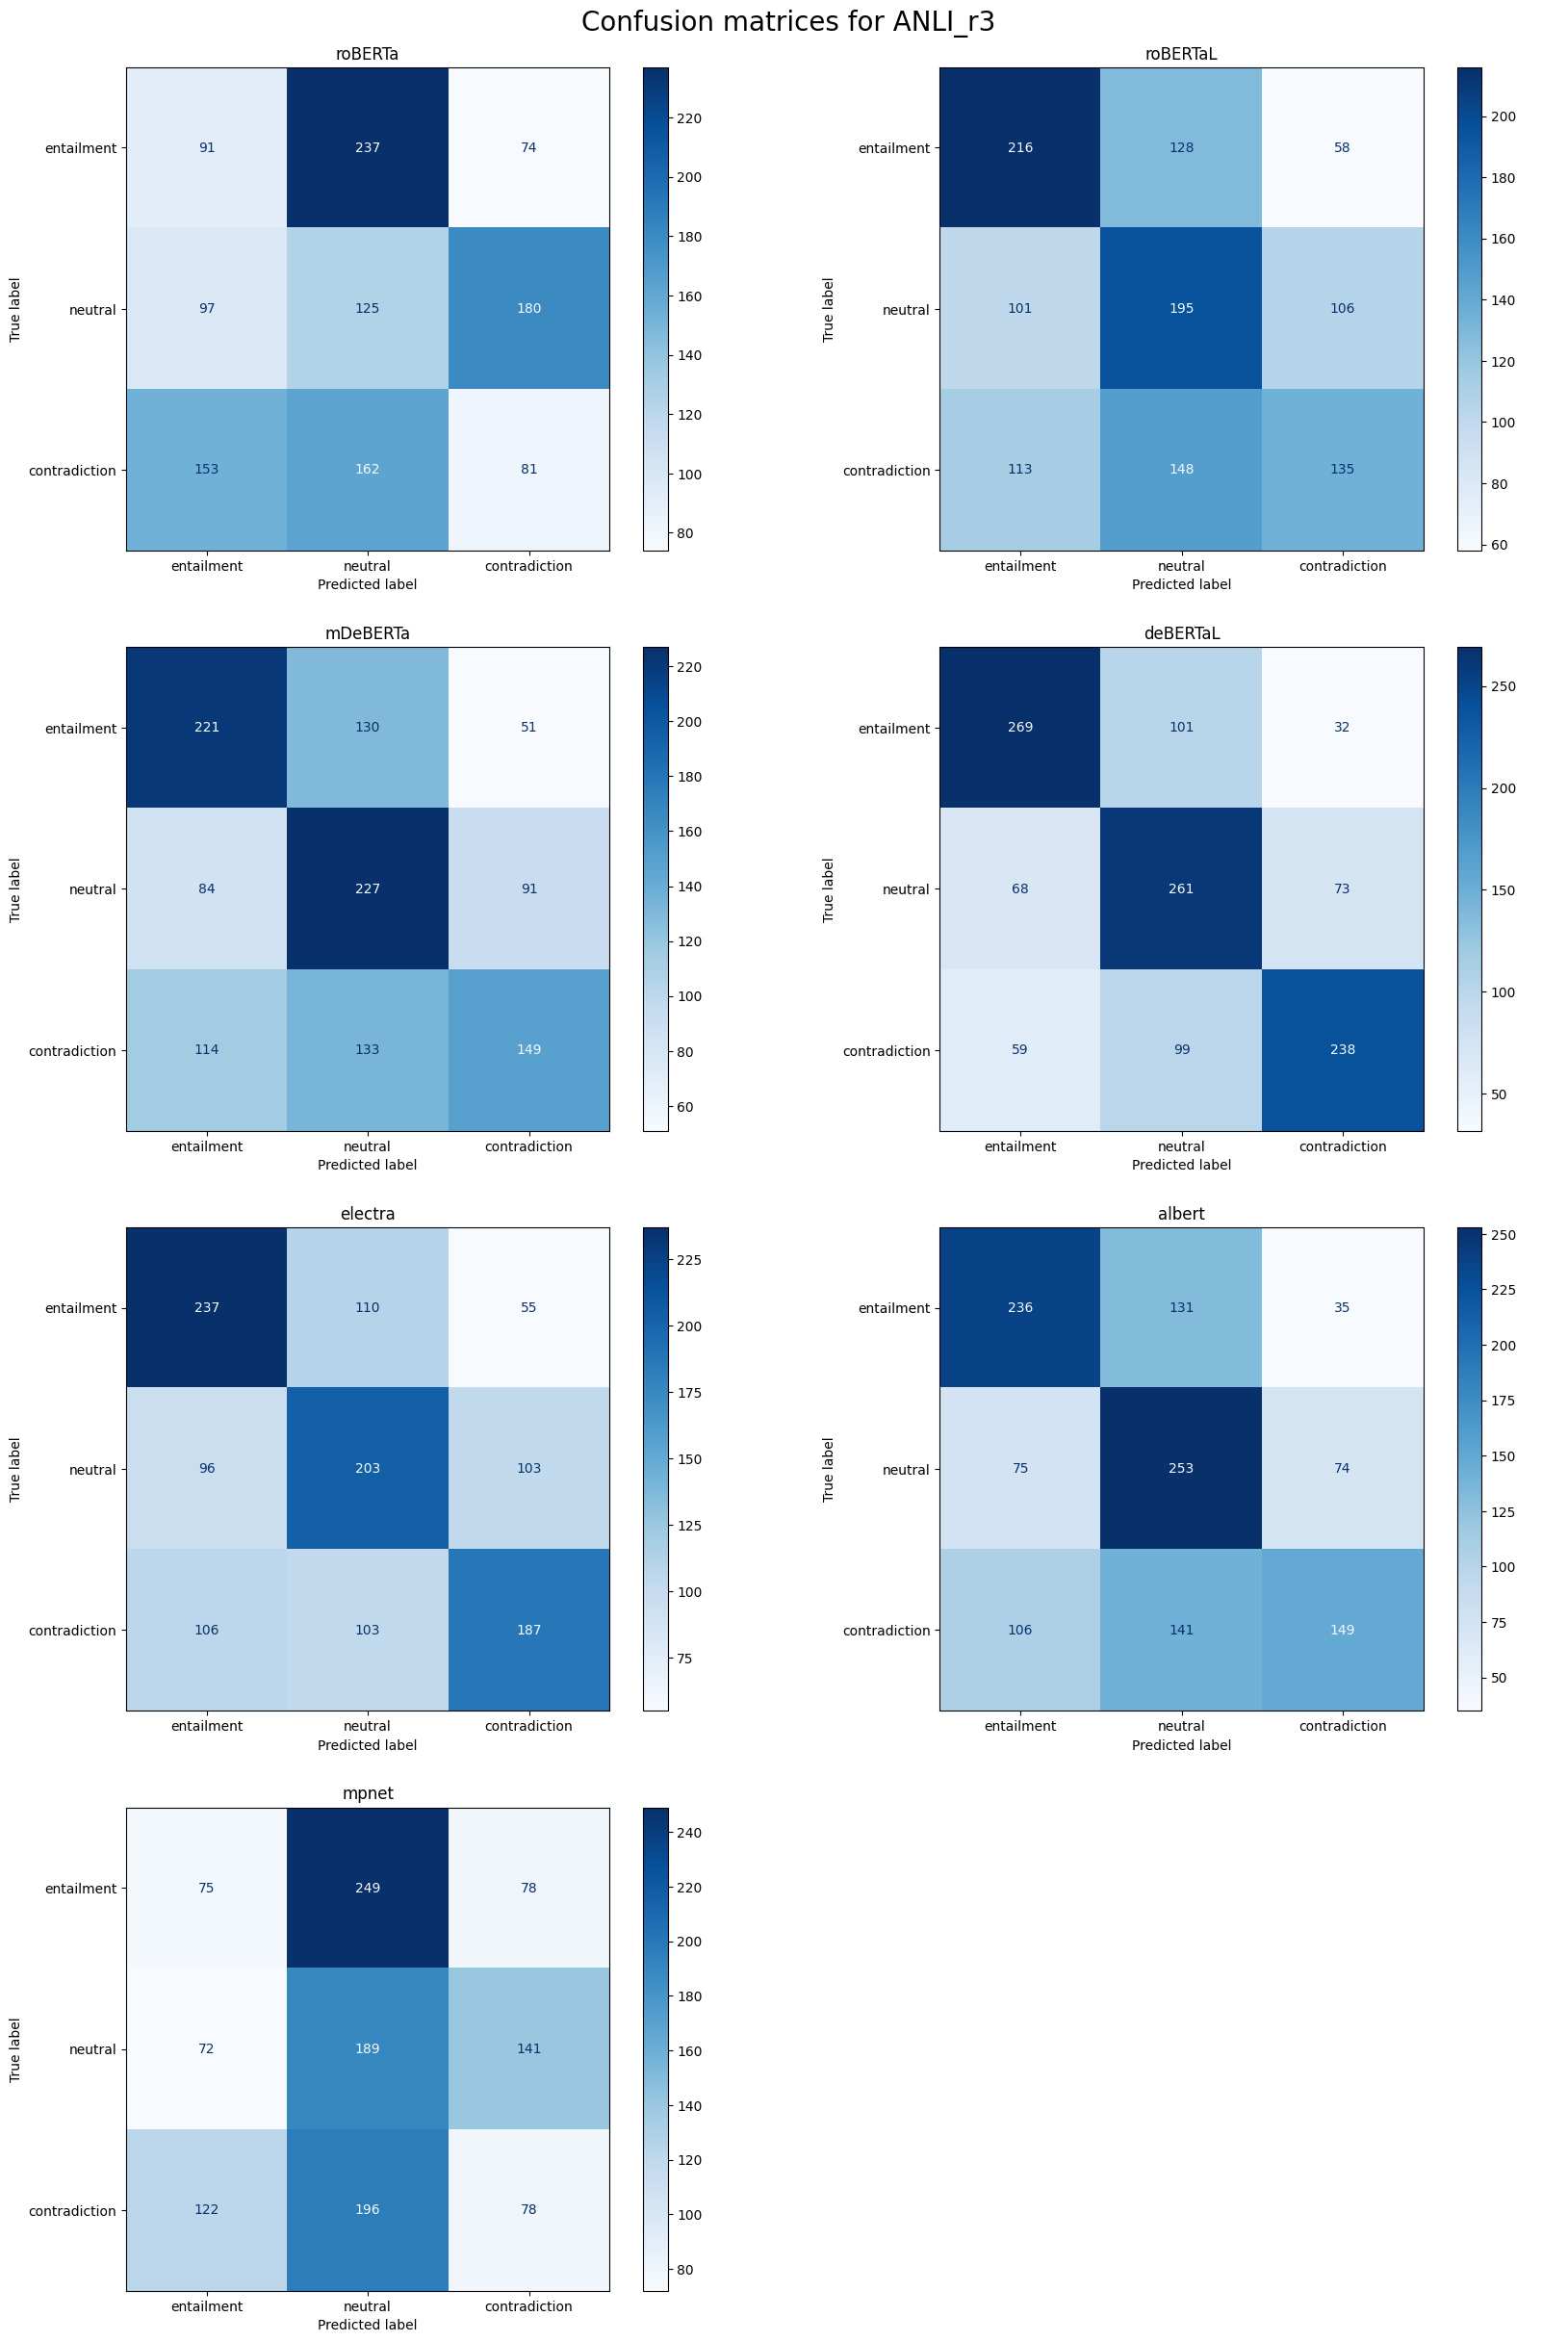

In [ ]:
printMetrics(convertToDict("ANLI_r3-results.txt"), eval_metrics, "ANLI_r3")

#### Discussion

In all three ANLI datasets *deBERTaL* is the model to perform best, achieving accuracies of about 80%, 70% and 60% in the progressively more difficult "r1", "r2" and "r3" sets.

In "ANLI r1" *roBERTaL* and *albert* followed *deBERTaL*'s leadership quite well with accuracies of about 70%, whereas *roBERTa* and *mpnet* struggled with 40% and 30% respectively. From their confusion matrices we see that they even often missclassified 'contradiction' examples as 'entailment'.

For "ANLI r2" the situation is similar, except *electra* overtaking *deBERTaL*. *roBERTa* and *mpnet* continue to perform worst, missclassifying 'neutral' as 'contradiction' and 'contradiction' as 'entailment' or 'neutral'.

In "ANLI r3" *roBERTaL*, *mDeBERTa*, *albert* and *electra* all stay around 50% accuracy, while *roBERTa* and *mpnet* remain behind with a score of about 25%, mistaking most of the time 'entailment' examples for 'neutral' ones.

As for the other datasets, *albert* takes the longest time for classification.

### SciTail results

#### Plots

In [ ]:
eval_metrics_scitail = ["accuracy","ent_precision","ent_recall", "ent_f1_score", "neut_precision","neut_recall", "neut_f1_score", "runtime", "conf_matrix"]

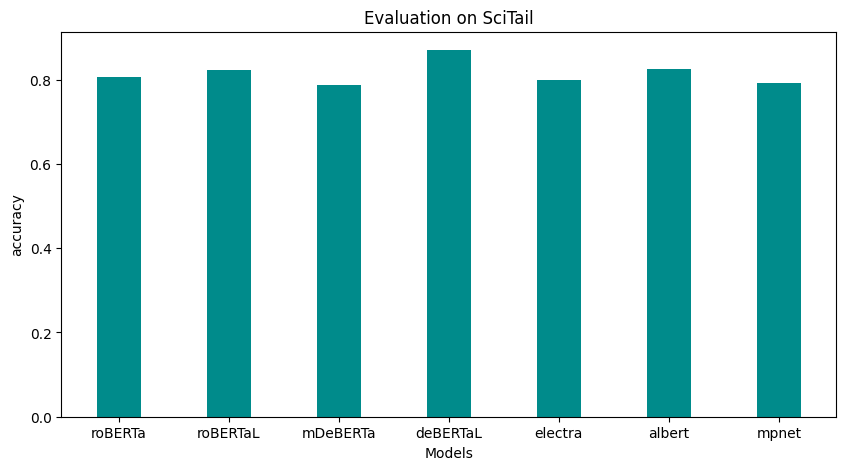

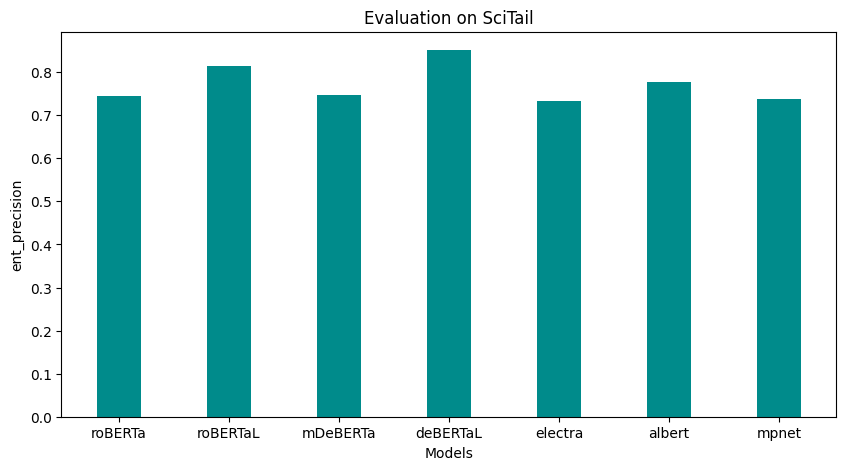

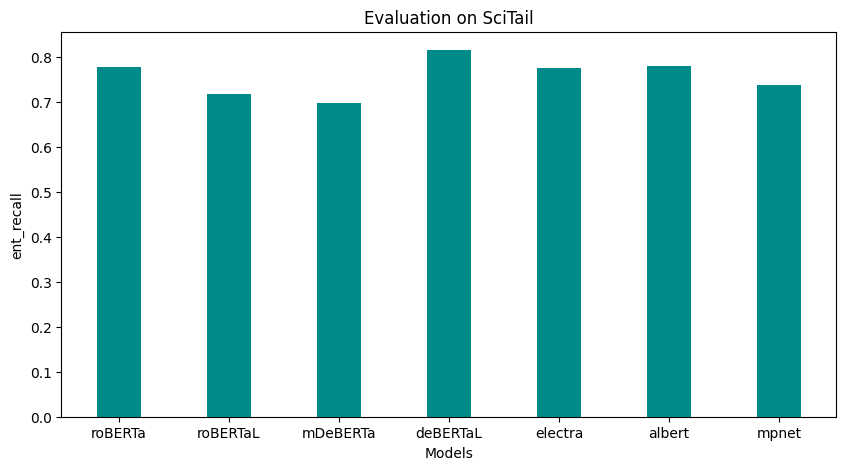

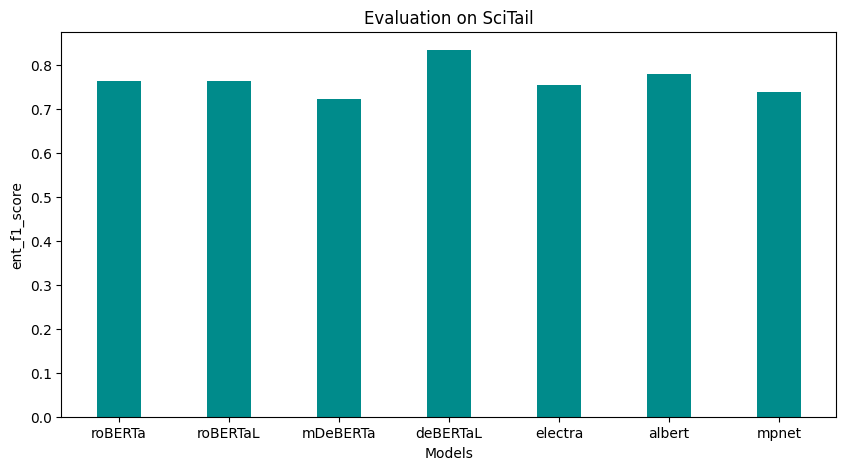

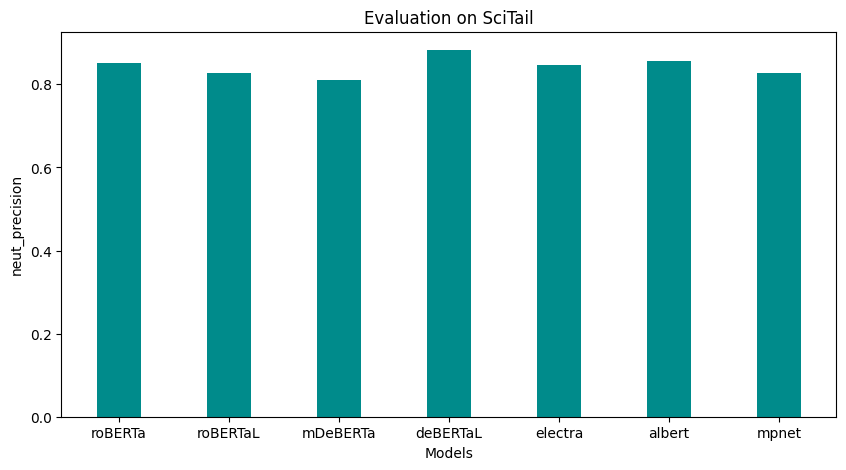

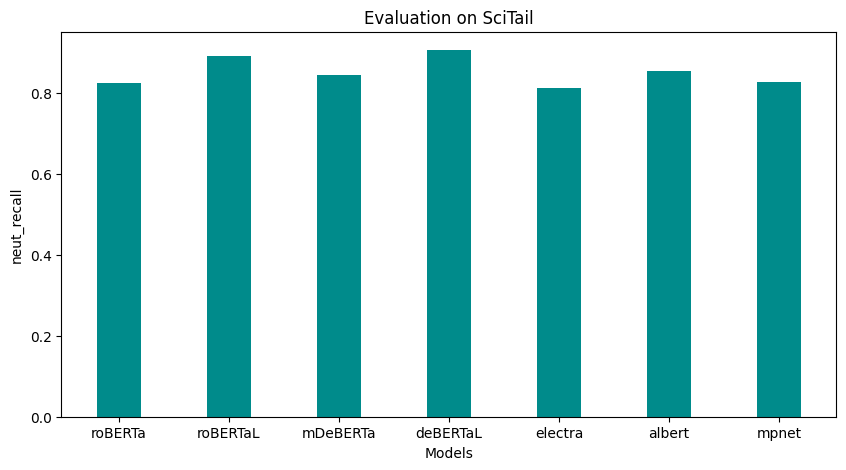

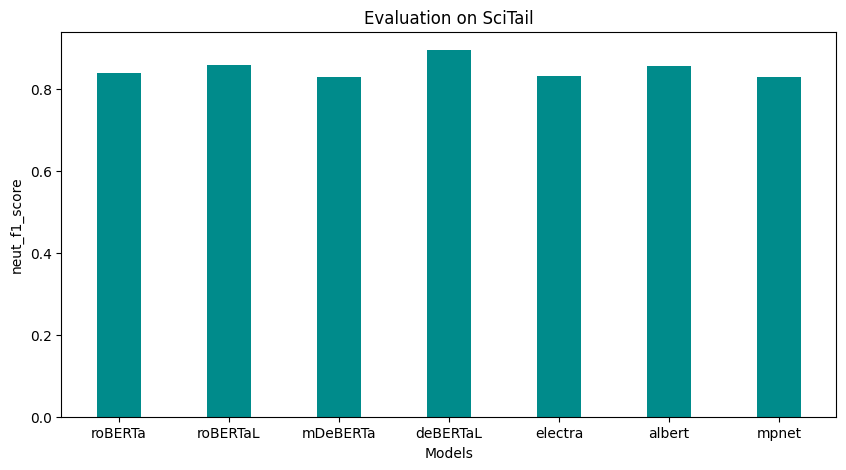

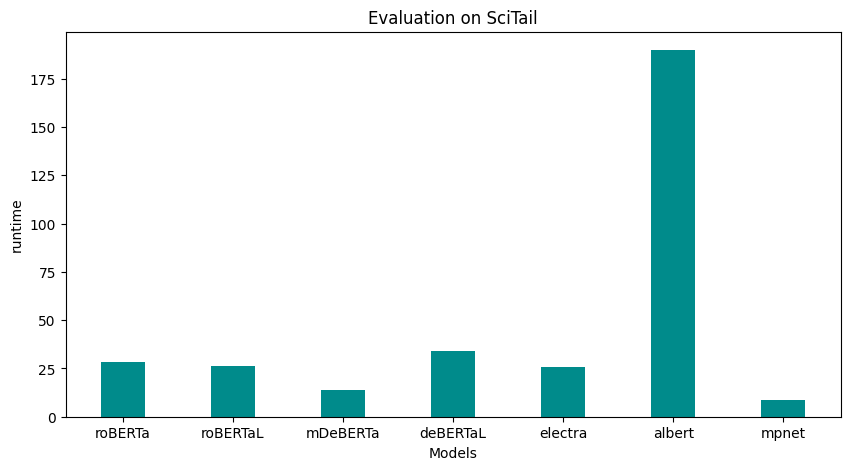

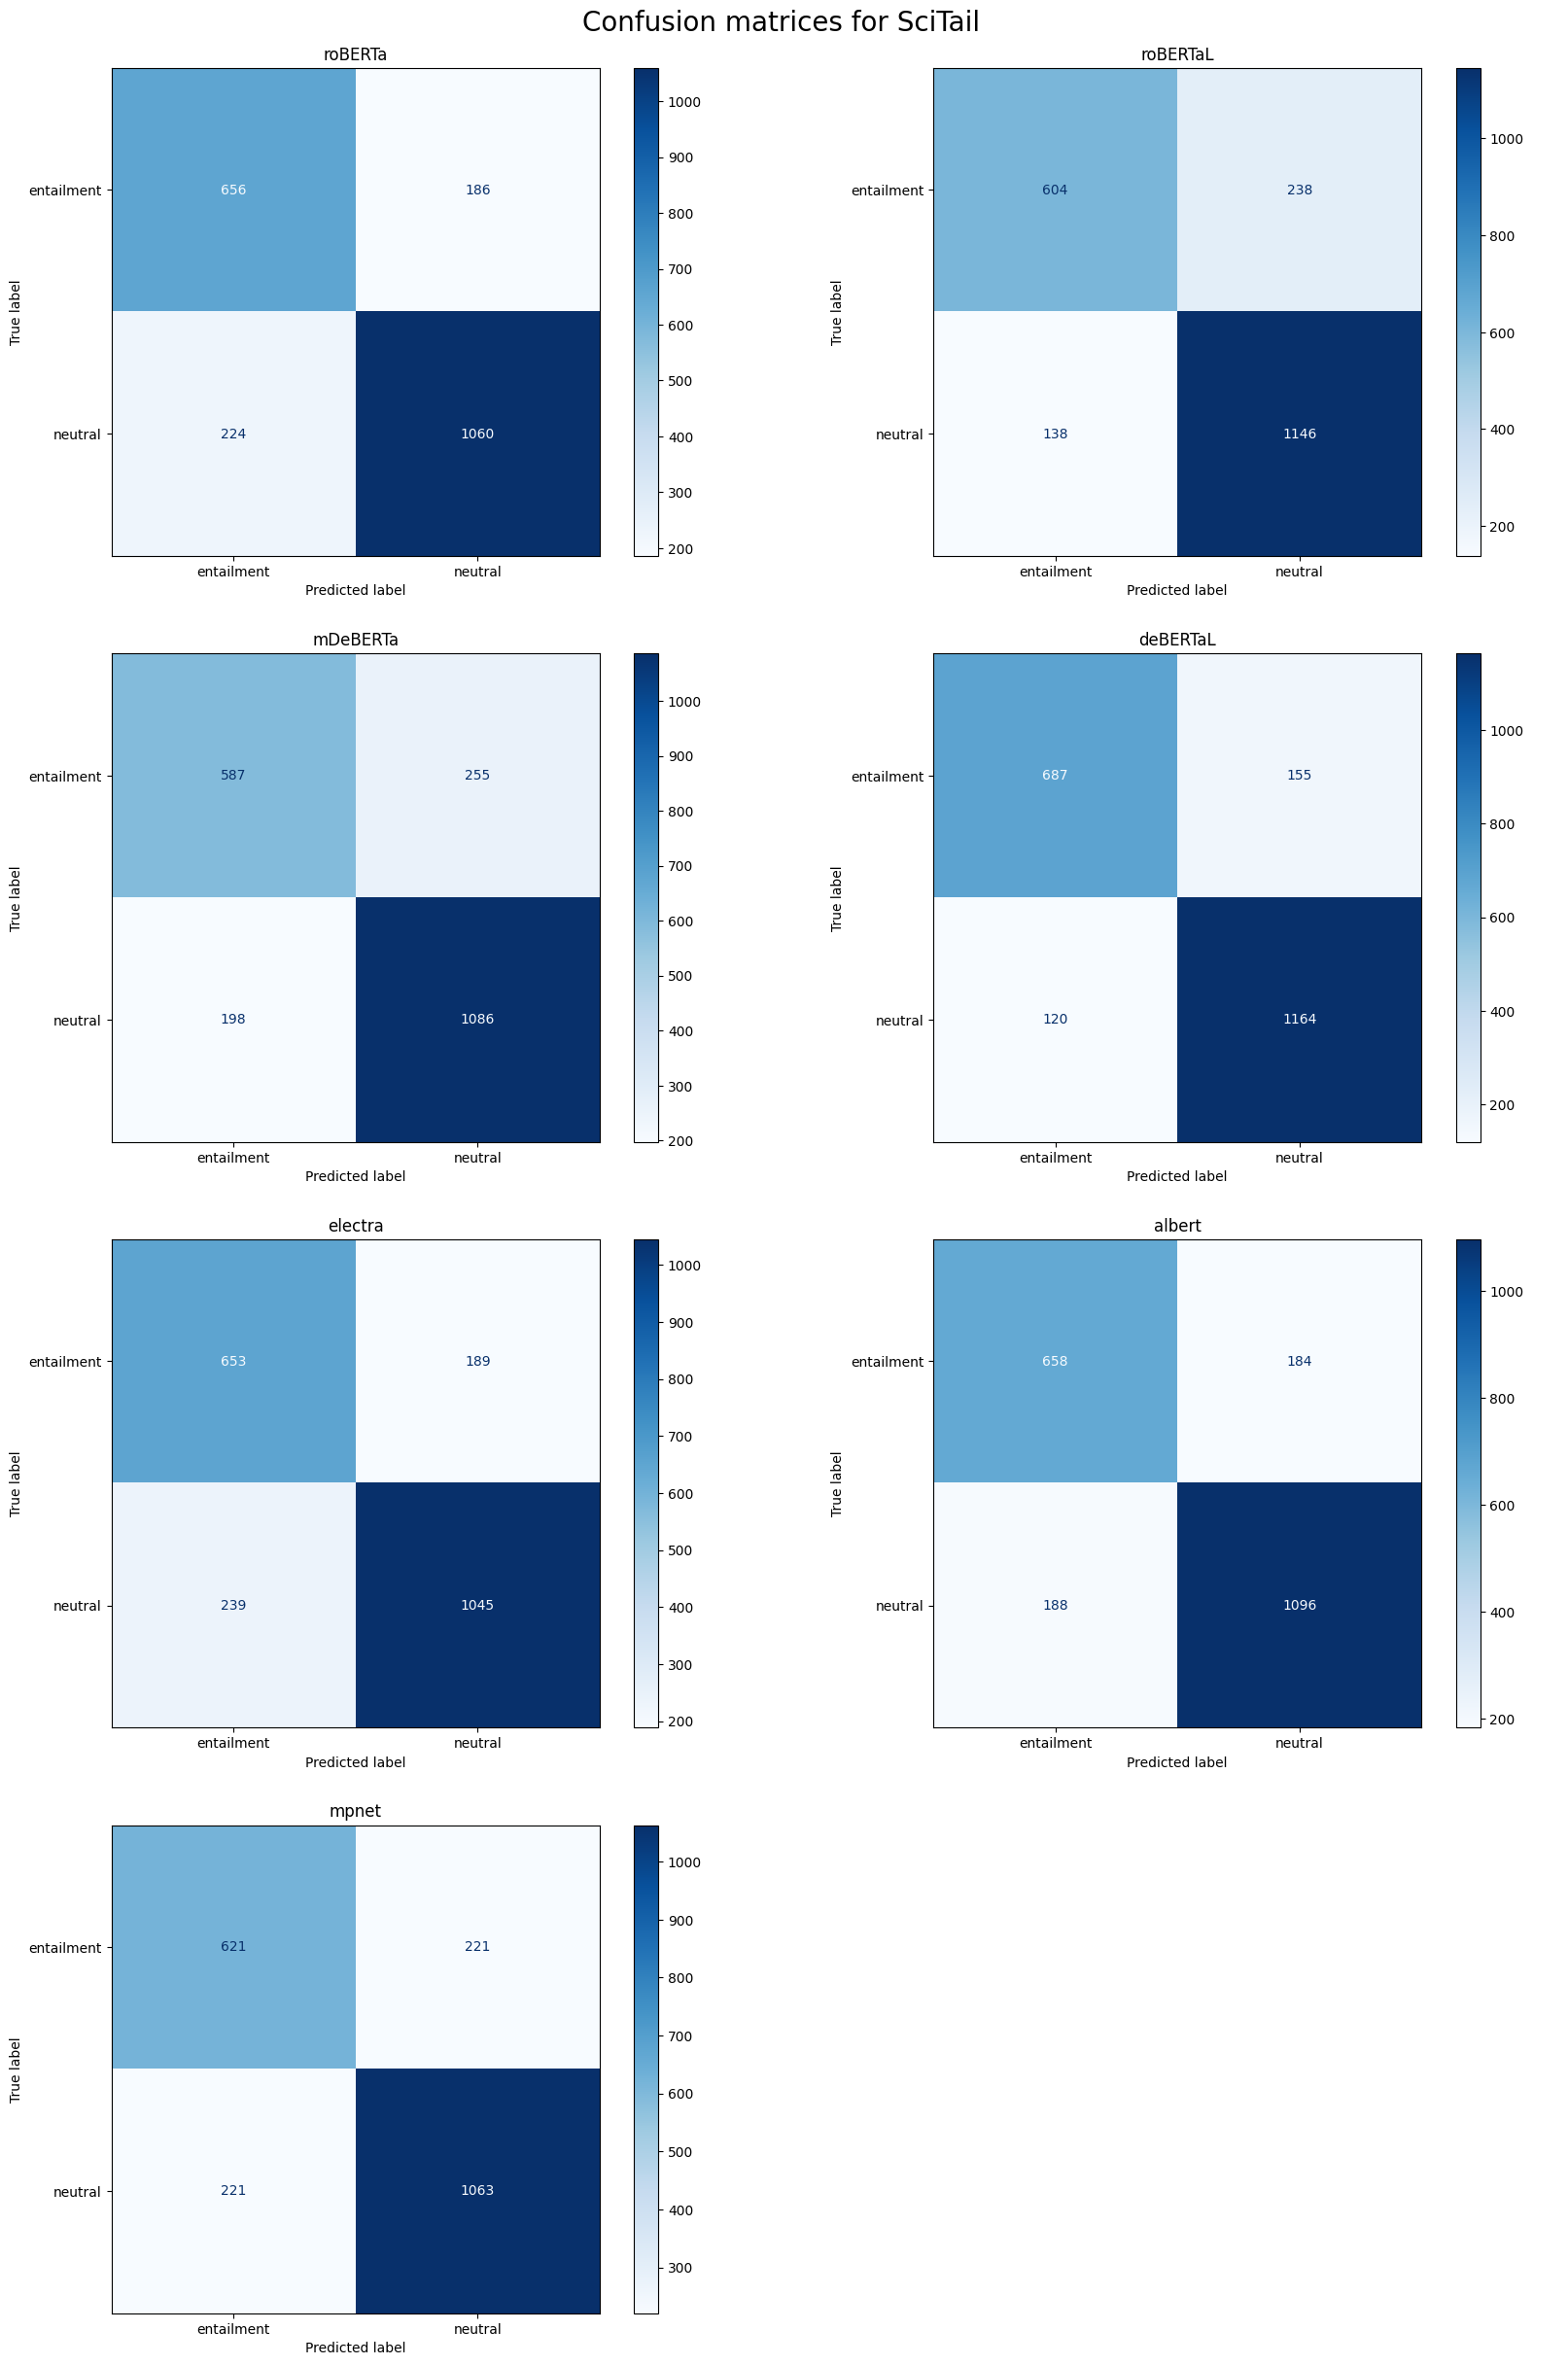

In [ ]:
printMetrics(convertToDict("SCITAIL-results.txt"), eval_metrics_scitail, "SciTail")

#### Discussion

In the 2-way TER SciTail dataset all of the models achieve an accuracy of about 80%, with *deBERTaL* performing best with 87%.

*albert*, as observed for the other datasets, takes the longest time for the task.